# LinkedIn Job Postings – Data Mining Notebook

Notebook tổng hợp cho đồ án *Khai phá dữ liệu* với 3 câu hỏi nghiên cứu:

- **RQ1:** Các mô tả công việc trên LinkedIn có tự nhiên hình thành những nhóm nội dung (job description themes) khác nhau hay không, khi không sử dụng bất kỳ nhãn nghề nghiệp hoặc kỹ năng có sẵn nào?
- **RQ2:** Các kỹ năng trong mô tả công việc có xu hướng đồng xuất hiện theo những mẫu nào, và những mẫu này phản ánh cấu trúc kỹ năng của thị trường lao động ra sao?
- **RQ3:** Những yếu tố nào trong thông tin tuyển dụng có ảnh hưởng đáng kể đến mức lương được công bố, và mức độ dự đoán lương từ các yếu tố này đến đâu?


# import libraries

In [8]:
import re

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from networkx.algorithms.community import greedy_modularity_communities
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestRegressor,
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.inspection import permutation_importance


plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
sns.set(style="whitegrid", font_scale=1.1)


In [9]:
def normalize_text(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"[^a-z0-9+# ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# 1. Load & Tổng quan dữ liệu

## 1.1 Load data

In [10]:
# Đặt đúng đường dẫn file trước khi chạy
JOB_POSTINGS_PATH = "../data/postings.csv"
COMPANIES_PATH = "../data/companies.csv"
EMP_COUNTS_PATH = "../data/employee_counts.csv"
JOB_SKILLS_PATH = "../data/job_skills.csv"
SKILL_MAP_PATH = "../data/skill_mapping.csv"

job_df = pd.read_csv(JOB_POSTINGS_PATH)
companies_df = pd.read_csv(COMPANIES_PATH)
emp_counts_df = pd.read_csv(EMP_COUNTS_PATH)
job_skills_df = pd.read_csv(JOB_SKILLS_PATH)
skill_map_df = pd.read_csv(SKILL_MAP_PATH)


In [11]:
# Gộp để lấy tên kỹ năng đầy đủ
job_skills_full = job_skills_df.merge(skill_map_df, on="skill_abr", how="left")

# Gom danh sách kỹ năng theo từng job_id
skills_per_job = (
    job_skills_full.dropna(subset=["skill_name"])
    .groupby("job_id")["skill_name"]
    .apply(list)
    .reset_index()
    .rename(columns={"skill_name": "linkedin_skills"})
)

In [12]:
job_df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [13]:
companies_df.head()

,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,Official LinkedIn of Hewlett Packard Enterpris...,7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packa...
3,1028,Oracle,We’re a cloud technology company that provides...,7.0,Texas,US,Austin,78741,2300 Oracle Way,https://www.linkedin.com/company/oracle
4,1033,Accenture,Accenture is a leading global professional ser...,7.0,0,IE,Dublin 2,0,Grand Canal Harbour,https://www.linkedin.com/company/accenture


In [14]:
emp_counts_df.head()

,company_id,employee_count,follower_count,time_recorded
0,391906,186,32508,1712346173
1,22292832,311,4471,1712346173
2,20300,1053,6554,1712346173
3,3570660,383,35241,1712346173
4,878353,52,26397,1712346173


In [15]:
skills_per_job.head()

,job_id,linkedin_skills
0,921716,"[Marketing, Sales]"
1,1218575,[Health Care Provider]
2,1829192,[Health Care Provider]
3,2264355,"[Design, Art/Creative, Information Technology]"
4,10998357,"[Management, Manufacturing]"


## 1.2 Thống kê mô tả

### 1.2.1 Độ lớn dữ liệu

In [16]:
print(f"job_df: {job_df.shape}")
print(f"companies_df: {companies_df.shape}")
print(f"emp_counts_df: {emp_counts_df.shape}")
print(f"skills_per_job_df: {skills_per_job.shape}")

job_df: (123849, 31)
companies_df: (24473, 10)
emp_counts_df: (35787, 4)
skills_per_job_df: (126807, 2)


### 1.2.2 Thông tin kiểu dữ liệu của data

In [17]:
job_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [18]:
companies_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24473 entries, 0 to 24472
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   company_id    24473 non-null  int64  
 1   name          24472 non-null  object 
 2   description   24176 non-null  object 
 3   company_size  21699 non-null  float64
 4   state         24451 non-null  object 
 5   country       24473 non-null  object 
 6   city          24472 non-null  object 
 7   zip_code      24445 non-null  object 
 8   address       24451 non-null  object 
 9   url           24473 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 1.9+ MB


In [19]:
emp_counts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35787 entries, 0 to 35786
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   company_id      35787 non-null  int64
 1   employee_count  35787 non-null  int64
 2   follower_count  35787 non-null  int64
 3   time_recorded   35787 non-null  int64
dtypes: int64(4)
memory usage: 1.1 MB


In [20]:
skills_per_job.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126807 entries, 0 to 126806
Data columns (total 2 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   job_id           126807 non-null  int64 
 1   linkedin_skills  126807 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.9+ MB


### 1.2.3 Thống kê mô tả

In [21]:
job_df.drop(columns="job_id").describe()

,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code,fips
count,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000
mean,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887
std,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825
min,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000
25%,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000
50%,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000
75%,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000
max,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000


In [22]:
companies_df.describe()

,company_id,company_size
count,2.447300e+04,21699.000000
mean,2.052239e+07,3.349233
std,3.165929e+07,1.904503
min,1.009000e+03,1.000000
25%,1.654040e+05,2.000000
50%,2.738154e+06,3.000000
75%,2.624142e+07,5.000000
max,1.034730e+08,7.000000


In [23]:
emp_counts_df.describe()

,company_id,employee_count,follower_count,time_recorded
count,3.578700e+04,35787.000000,3.578700e+04,3.578700e+04
mean,1.668254e+07,6715.874256,2.012616e+05,1.713163e+09
std,2.924722e+07,29400.984643,1.114733e+06,3.990869e+05
min,1.009000e+03,0.000000,0.000000e+00,1.712346e+09
25%,6.059650e+04,56.000000,2.738000e+03,1.712861e+09
50%,1.339209e+06,418.000000,1.617800e+04,1.713393e+09
75%,1.544092e+07,2945.000000,7.412950e+04,1.713472e+09
max,1.034730e+08,751125.000000,3.270284e+07,1.713573e+09


## 1.3 Tích hợp dữ liệu

In [24]:
# Merge job với thông tin công ty
job_merged = job_df.merge(companies_df, on="company_id", how="left")

# Sau khi merge, có thể xuất hiện description_x (job) và description_y (company)
# Chuẩn hóa lại để luôn có đúng một cột 'description' cho mô tả job
desc_cols = [c for c in job_merged.columns if "description" in c]
if "description" not in job_merged.columns:
    # Ưu tiên description_x nếu có (từ job_df)
    if "description_x" in job_merged.columns:
        job_merged["description"] = job_merged["description_x"]
    elif len(desc_cols) > 0:
        job_merged["description"] = job_merged[desc_cols[0]]
# Xóa các cột description trùng lặp khác (giữ lại 'description')
for c in desc_cols:
    if c != "description":
        job_merged.drop(columns=[c], inplace=True)

# Lấy bản ghi employee_count mới nhất cho mỗi công ty
emp_latest = emp_counts_df.sort_values("time_recorded").groupby("company_id").tail(1)
job_merged = job_merged.merge(
    emp_latest[["company_id", "employee_count", "follower_count"]],
    on="company_id",
    how="left",
)

# Merge skill vào job_merged
job_merged = job_merged.merge(skills_per_job, on="job_id", how="left")

print("Kích thước sau khi merge:", job_merged.shape)
job_merged.head()

Kích thước sau khi merge: (123849, 42)


,job_id,company_name,title,max_salary,pay_period,location,company_id,views,med_salary,min_salary,...,state,country,city,zip_code_y,address,url,description,employee_count,follower_count,linkedin_skills
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,17.0,...,NJ,US,Jersey City,07302,242 Tenth Street,https://www.linkedin.com/company/corcoran-sawy...,Job descriptionA leading real estate firm in N...,402.0,2351.0,"[Marketing, Sales]"
1,1829192,NaN,Mental Health Therapist/Counselor,50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,30.0,...,NaN,NaN,NaN,NaN,NaN,NaN,"At Aspen Therapy and Wellness , we are committ...",NaN,NaN,[Health Care Provider]
2,10998357,The National Exemplar,Assitant Restaurant Manager,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,45000.0,...,Ohio,US,Mariemont,45227,6880 Wooster Pike,https://www.linkedin.com/company/the-national-...,The National Exemplar is accepting application...,15.0,40.0,"[Management, Manufacturing]"
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,140000.0,...,New York,US,Lake Success,11042,3 Dakota Drive,https://www.linkedin.com/company/abrams-fenste...,Senior Associate Attorney - Elder Law / Trusts...,222.0,2427.0,[Other]
4,35982263,NaN,Service Technician,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,60000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Looking for HVAC service tech with experience ...,NaN,NaN,[Information Technology]


In [25]:
job_merged.describe()

,job_id,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code_x,fips,company_size,employee_count,follower_count
count,1.238490e+05,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000,117142.000000,122131.000000,1.221310e+05
mean,3.896402e+09,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887,4.935420,17452.960444,5.029376e+05
std,8.404355e+07,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825,2.054749,59150.405648,2.297005e+06
min,9.217160e+05,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000,1.000000,0.000000,0.000000e+00
25%,3.894587e+09,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000,3.000000,188.000000,1.207800e+04
50%,3.901998e+09,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000,5.000000,1686.000000,5.334400e+04
75%,3.904707e+09,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000,7.000000,11289.000000,2.110300e+05
max,3.906267e+09,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000,7.000000,748312.000000,3.270284e+07


# 2. EDA – Khám phá dữ liệu

## 2.1 Tỷ lệ thiếu dữ liệu theo cột quan trọng

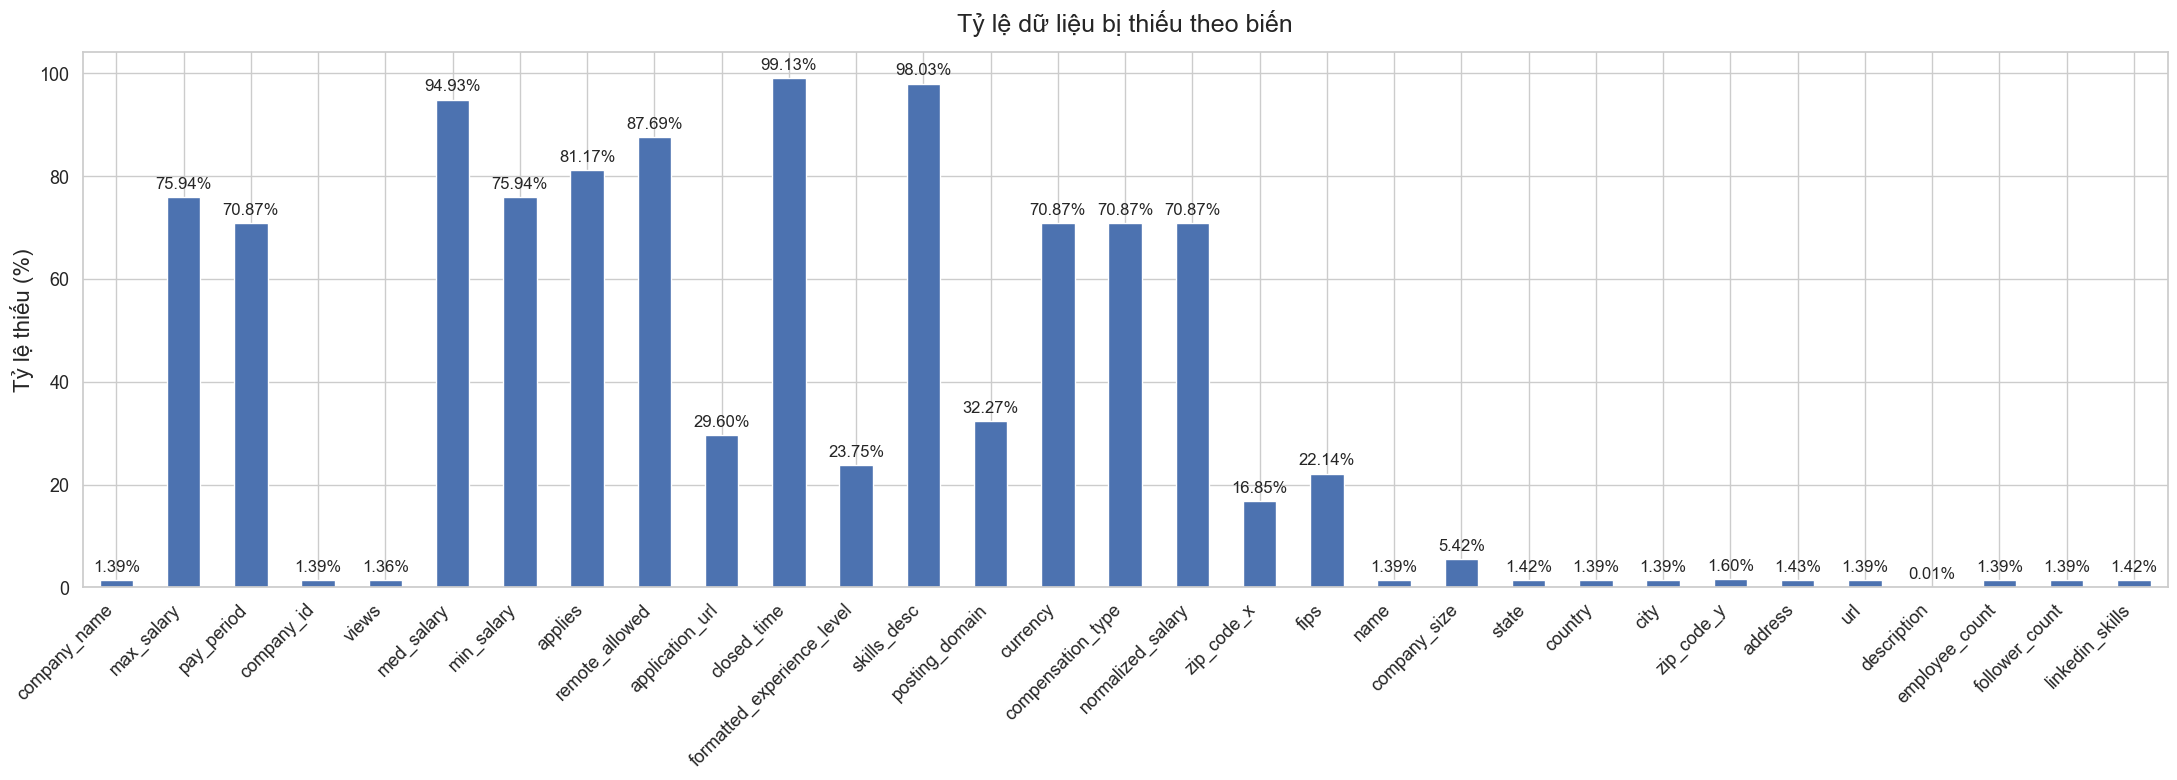

In [26]:
# tính missing
missing_percent = job_merged.isnull().mean() * 100
missing_count = job_merged.isnull().sum()
cols_with_missing = missing_count[missing_count > 0].index

# tạo figure + axis
fig, ax = plt.subplots(figsize=(22, 8))

# vẽ bar chart
missing_percent[cols_with_missing].plot(kind="bar", ax=ax)

# label & title (TĂNG FONT)
ax.set_ylabel("Tỷ lệ thiếu (%)", fontsize=16)
ax.set_title("Tỷ lệ dữ liệu bị thiếu theo biến", fontsize=18, pad=15)

# trục x (TĂNG FONT)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=13)

# trục y (TĂNG FONT)
ax.tick_params(axis="y", labelsize=13)

# thêm giá trị lên mỗi cột (TĂNG FONT)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}%",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=12,
        xytext=(0, 4),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()


## 2.2 Tiền xử lí dữ liệu

In [27]:
# làm sạch biến địa lí
for col in ["country", "state", "city"]:
    if col in job_merged.columns:
        job_merged[col] = job_merged[col].replace("0", np.nan)
        job_merged[col] = job_merged[col].fillna("Unknown")

# chuẩn hóa dữ liệu kiểu số
numeric_cols = [
    "min_salary",
    "med_salary",
    "max_salary",
    "normalized_salary",
    "views",
    "applies",
    "employee_count",
    "follower_count",
]

for col in numeric_cols:
    if col in job_merged.columns:
        job_merged[col] = pd.to_numeric(job_merged[col], errors="coerce")

# xử lí mô tả công việc và tạo cột mới
job_merged["description"] = job_merged["description"].fillna("")
job_merged["description_norm"] = (
    job_merged["description"].fillna("").apply(normalize_text)
)

# 1. Chuẩn hóa giá trị formatted_experience_level
job_merged["formatted_experience_level"] = (
    job_merged["formatted_experience_level"]
    .astype(str)
    .str.strip()
)

# Quy về nhóm thống nhất
exp_map = {
    "Internship": "Intern",
    "Entry level": "Entry",
    "Associate": "Entry",
    "Mid-Senior level": "Mid",
    "Director": "Senior",
    "Executive": "Executive",
    "nan": np.nan
}

job_merged["formatted_experience_level"] = (
    job_merged["formatted_experience_level"]
    .replace(exp_map)
)

# 2. Hàm trích experience level từ title (chỉ dùng để fill NaN)
def extract_exp_from_title(title: str):
    if pd.isna(title):
        return np.nan
    t = title.lower()
    if re.search(r"\b(intern|internship|trainee)\b", t):
        return "Intern"
    if re.search(r"\b(junior|jr\.?)\b", t):
        return "Entry"
    if re.search(r"\b(senior|sr\.?)\b", t):
        return "Senior"
    if re.search(r"\b(lead|principal|staff)\b", t):
        return "Senior"
    if re.search(r"\b(manager|head)\b", t):
        return "Mid"
    if re.search(r"\b(director|vp|vice president)\b", t):
        return "Senior"
    if re.search(r"\b(c-level|cto|cfo|ceo|chief)\b", t):
        return "Executive"
    return np.nan

# 3. Fill missing formatted_experience_level bằng title
mask_missing = job_merged["formatted_experience_level"].isna()
job_merged.loc[mask_missing, "formatted_experience_level"] = (
    job_merged.loc[mask_missing, "title"]
    .apply(extract_exp_from_title)
)

# 4. Fill còn thiếu bằng giá trị phổ biến nhất
job_merged["formatted_experience_level"] = (
    job_merged["formatted_experience_level"]
    .fillna("Unknown")
)



In [28]:
job_merged.describe()

,job_id,max_salary,company_id,views,med_salary,min_salary,applies,original_listed_time,remote_allowed,expiry,closed_time,listed_time,sponsored,normalized_salary,zip_code_x,fips,company_size,employee_count,follower_count
count,1.238490e+05,2.979300e+04,1.221320e+05,122160.000000,6280.000000,2.979300e+04,23320.000000,1.238490e+05,15246.0,1.238490e+05,1.073000e+03,1.238490e+05,123849.0,3.607300e+04,102977.000000,96434.000000,117142.000000,122131.000000,1.221310e+05
mean,3.896402e+09,9.193942e+04,1.220401e+07,14.618247,22015.619876,6.491085e+04,10.591981,1.713152e+12,1.0,1.716213e+12,1.712928e+12,1.713204e+12,0.0,2.053270e+05,50400.491887,28713.879887,4.935420,17452.960444,5.029376e+05
std,8.404355e+07,7.011101e+05,2.554143e+07,85.903598,52255.873846,4.959738e+05,29.047395,4.848209e+08,0.0,2.321394e+09,3.622893e+08,3.989122e+08,0.0,5.097627e+06,30252.232515,16015.929825,2.054749,59150.405648,2.297005e+06
min,9.217160e+05,1.000000e+00,1.009000e+03,1.000000,0.000000,1.000000e+00,1.000000,1.701811e+12,1.0,1.712903e+12,1.712346e+12,1.711317e+12,0.0,0.000000e+00,1001.000000,1003.000000,1.000000,0.000000,0.000000e+00
25%,3.894587e+09,4.828000e+01,1.435200e+04,3.000000,18.940000,3.700000e+01,1.000000,1.712863e+12,1.0,1.715481e+12,1.712670e+12,1.712886e+12,0.0,5.200000e+04,24112.000000,13121.000000,3.000000,188.000000,1.207800e+04
50%,3.901998e+09,8.000000e+04,2.269650e+05,4.000000,25.500000,6.000000e+04,3.000000,1.713395e+12,1.0,1.716042e+12,1.712670e+12,1.713408e+12,0.0,8.150000e+04,48059.000000,29183.000000,5.000000,1686.000000,5.334400e+04
75%,3.904707e+09,1.400000e+05,8.047188e+06,8.000000,2510.500000,1.000000e+05,8.000000,1.713478e+12,1.0,1.716088e+12,1.713283e+12,1.713484e+12,0.0,1.250000e+05,78201.000000,42077.000000,7.000000,11289.000000,2.110300e+05
max,3.906267e+09,1.200000e+08,1.034730e+08,9975.000000,750000.000000,8.500000e+07,967.000000,1.713573e+12,1.0,1.729125e+12,1.713562e+12,1.713573e+12,0.0,5.356000e+08,99901.000000,56045.000000,7.000000,748312.000000,3.270284e+07


## 2.3 Trực quan hóa dữ liệu

### 2.3.1 Phân bố job theo country (top 10)

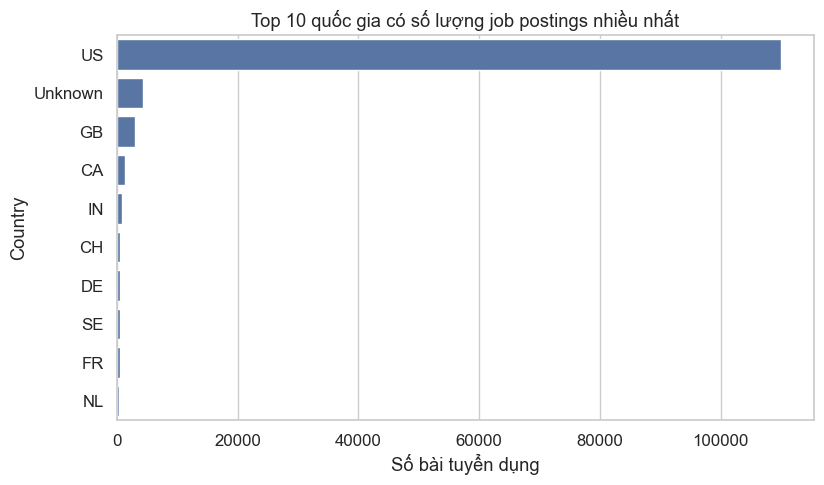

In [29]:
top_countries = job_merged["country"].value_counts().head(10)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.xlabel("Số bài tuyển dụng")
plt.ylabel("Country")
plt.title("Top 10 quốc gia có số lượng job postings nhiều nhất")
plt.show()

### 2.3.2 Biểu đồ mối quan hệ giữa lượt xem và lượt ứng tuyển

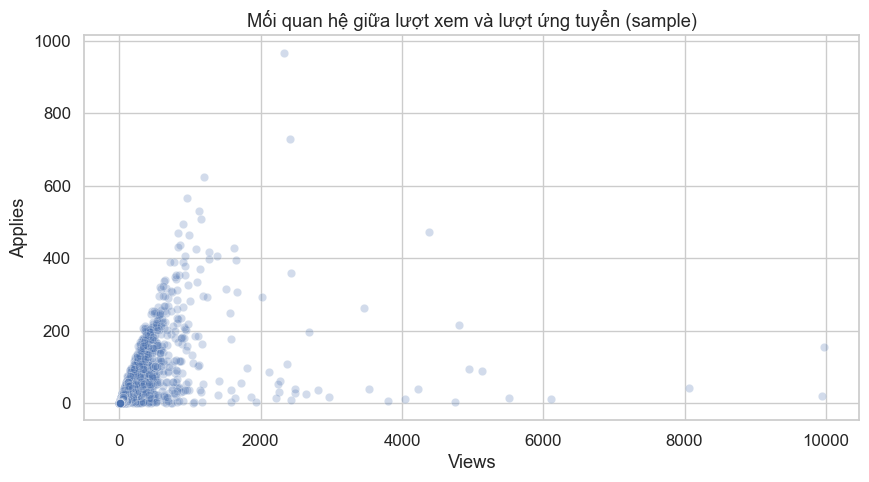

In [30]:
tmp = job_merged[["views", "applies"]].dropna().copy()
tmp = tmp[(tmp["views"] >= 0) & (tmp["applies"] >= 0)]

sns.scatterplot(data=tmp, x="views", y="applies", alpha=0.25)
plt.xlabel("Views")
plt.ylabel("Applies")
plt.title("Mối quan hệ giữa lượt xem và lượt ứng tuyển (sample)")
plt.show()

# 3. RQ1 – Phân cụm 

## 3.1 Chuẩn bị dữ liệu

In [31]:
TEXT_COL = "description_norm"
job_text = job_merged[["job_id", "title", TEXT_COL]].dropna(subset=[TEXT_COL]).copy()

job_text_sample = job_text.reset_index(drop=True)

print("Số JD dùng cho RQ1 clustering:", len(job_text_sample))

Số JD dùng cho RQ1 clustering: 123849


## 3.2 TF-IDF vectorization (themes)

Trong bước này, mô tả công việc (`description`) được chuyển đổi từ dữ liệu văn bản thô sang dạng vector số bằng phương pháp **TF-IDF (Term Frequency – Inverse Document Frequency)**. TF-IDF giúp đo lường mức độ quan trọng của một từ trong một tài liệu so với toàn bộ tập dữ liệu, qua đó giảm ảnh hưởng của các từ quá phổ biến và làm nổi bật các thuật ngữ mang tính phân biệt nội dung.

Các tham số chính được thiết lập như sau:

* **`stop_words="english"`**: loại bỏ các từ dừng tiếng Anh (ví dụ: *the, and, is*), vốn không mang nhiều ý nghĩa phân biệt nội dung.
* **`max_features=30000`**: giới hạn số lượng đặc trưng TF-IDF tối đa nhằm kiểm soát kích thước không gian đặc trưng và chi phí tính toán.
* **`ngram_range=(1, 2)`**: sử dụng cả unigram và bigram để nắm bắt không chỉ các từ đơn lẻ mà còn các cụm từ ngắn thường xuất hiện trong mô tả công việc (ví dụ: *project management*, *data analysis*).
* **`min_df=10`**: loại bỏ các từ/cụm từ xuất hiện quá ít (dưới 10 tài liệu), giúp giảm nhiễu và các thuật ngữ không đại diện.
* **`max_df=0.80`**: loại bỏ các từ xuất hiện trong hơn 80% số tài liệu, thường là các từ mang tính khuôn mẫu hoặc boilerplate trong mô tả tuyển dụng.

Kết quả của bước này là một **ma trận TF-IDF thưa (sparse matrix)** với kích thước `(số lượng job descriptions, số lượng đặc trưng TF-IDF)`. Ma trận này đóng vai trò là đầu vào cho các thuật toán phân cụm trong RQ1, giúp khám phá các nhóm nội dung (job description themes) tiềm ẩn mà không cần sử dụng bất kỳ nhãn nghề nghiệp hay kỹ năng có sẵn nào.

In [32]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=30000,
    ngram_range=(1, 2),
    min_df=10,  # bỏ từ quá hiếm
    max_df=0.80,  # bỏ từ quá phổ biến (boilerplate)
)
X = tfidf.fit_transform(job_text_sample[TEXT_COL])
print("TF-IDF matrix:", X.shape)

TF-IDF matrix: (123849, 30000)


## 3.3 Chạy K-Means

In [33]:
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
job_text_sample["cluster"] = kmeans.fit_predict(X)

## 3.4 Tìm Top keywords

In [34]:
def top_terms_per_cluster(model, vectorizer, n_terms=15):
    terms = np.array(vectorizer.get_feature_names_out())
    order_centroids = model.cluster_centers_.argsort()[:, ::-1]
    cluster_terms = {}
    for i in range(model.n_clusters):
        cluster_terms[i] = terms[order_centroids[i, :n_terms]]
    return cluster_terms


cluster_keywords = top_terms_per_cluster(kmeans, tfidf, n_terms=15)

print("\nTop keywords per cluster:")
for cid, kws in cluster_keywords.items():
    print(f"Cluster {cid}: {', '.join(kws[:15])}")


Top keywords per cluster:
Cluster 0: design, software, technical, engineering, security, systems, development, cloud, solutions, product, business, team, support, engineer, skills
Cluster 1: students, student, school, learning, teaching, teacher, classroom, teachers, education, curriculum, academic, district, schools, fedex ground, children
Cluster 2: store, customer, sales, merchandise, customers, retail, store manager, service, manager, associates, customer service, company, team, associate, merchandising
Cluster 3: team, business, management, skills, company, job, customer, support, including, benefits, position, service, clients, time, client
Cluster 4: equipment, safety, maintenance, required, ability, job, perform, company, duties, service, able, customer, production, food, position
Cluster 5: accounting, financial, tax, finance, reporting, accountant, accounts, monthly, analysis, degree accounting, business, accounting finance, cpa, statements, company
Cluster 6: care, nursing,

**Nhận xét**

**Meta-theme 1: Công nghệ thông tin – Phát triển phần mềm – Dữ liệu**

**Clusters:** 0, 7, 13

* **Cluster 0:** *software, engineering, cloud, security, systems*
* **Cluster 7:** *project management, engineering, technical development*
* **Cluster 13:** *data, analytics, SQL, BI, Python, insights*

=>️ Meta-theme này phản ánh **các mô tả công việc thiên về kỹ thuật số**, bao gồm phát triển phần mềm, hạ tầng CNTT, quản lý dự án kỹ thuật và phân tích dữ liệu. Đây là một **chủ đề nội dung lớn và xuyên ngành**, xuất hiện ở nhiều lĩnh vực khác nhau.

---

**Meta-theme 2: Giáo dục – Đào tạo**

**Cluster:** 1

* *students, school, teaching, classroom, education, curriculum*

=>️ Cluster này hình thành rất rõ ràng, cho thấy **mô tả công việc trong lĩnh vực giáo dục có ngôn ngữ và cấu trúc nội dung đặc thù**, tách biệt khỏi các ngành khác.

---

 **Meta-theme 3: Bán lẻ – Dịch vụ – Chăm sóc khách hàng**

**Clusters:** 2, 3, 10

* **Cluster 2:** *retail, store manager, merchandise, associates*
* **Cluster 3:** *customer support, service, benefits, company*
* **Cluster 10:** *sales, account, territory, relationships, products*

=>️ Các cluster này phản ánh **chủ đề nội dung xoay quanh bán hàng và dịch vụ**, từ bán lẻ tại cửa hàng đến bán hàng B2B và chăm sóc khách hàng. Ngôn ngữ JD nhấn mạnh tương tác khách hàng, doanh số và kỹ năng giao tiếp.

---

 **Meta-theme 4: Sản xuất – Vận hành – Lao động kỹ thuật**

**Cluster:** 4

* *equipment, safety, maintenance, production, duties*

=>️ Meta-theme này đại diện cho **các công việc vận hành và kỹ thuật thực địa**, với nội dung JD tập trung vào an toàn lao động, bảo trì thiết bị và nhiệm vụ vận hành.

---

 **Meta-theme 5: Tài chính – Kế toán – Kinh doanh chuyên môn**

**Clusters:** 5, 14

* **Cluster 5:** *accounting, financial, tax, CPA, reporting*
* **Cluster 14:** *earnings, credit, business owners, executive consultants*

=>️ Hai cluster này phản ánh **các vai trò tài chính – kế toán và kinh doanh cấp cao**, từ nghiệp vụ kế toán chuẩn mực đến tư vấn và kinh doanh chiến lược.

---

**Meta-theme 6: Y tế – Chăm sóc sức khỏe**

**Clusters:** 6, 9, 11, 12

* **Cluster 6 & 12:** *patient care, clinical, hospital, medical*
* **Cluster 9 & 11:** *nursing staffing, travel nurse, healthcare organizations*

=>️ Đây là meta-theme lớn với **nhiều cluster con**, phản ánh sự đa dạng trong lĩnh vực y tế: chăm sóc lâm sàng, điều dưỡng, tuyển dụng nhân lực y tế và dịch vụ chăm sóc sức khỏe.

## 3.5 Biểu đồ phân bố số lượng JD theo cluster

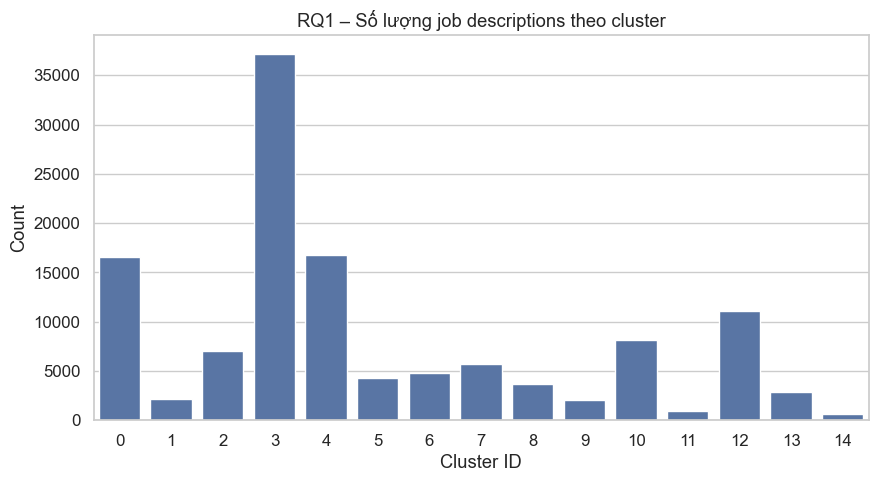

In [35]:
counts = job_text_sample["cluster"].value_counts().sort_index()
sns.barplot(x=counts.index, y=counts.values)
plt.title("RQ1 – Số lượng job descriptions theo cluster")
plt.xlabel("Cluster ID")
plt.ylabel("Count")
plt.show()

## 3.6 Trực quan hóa t-SNE

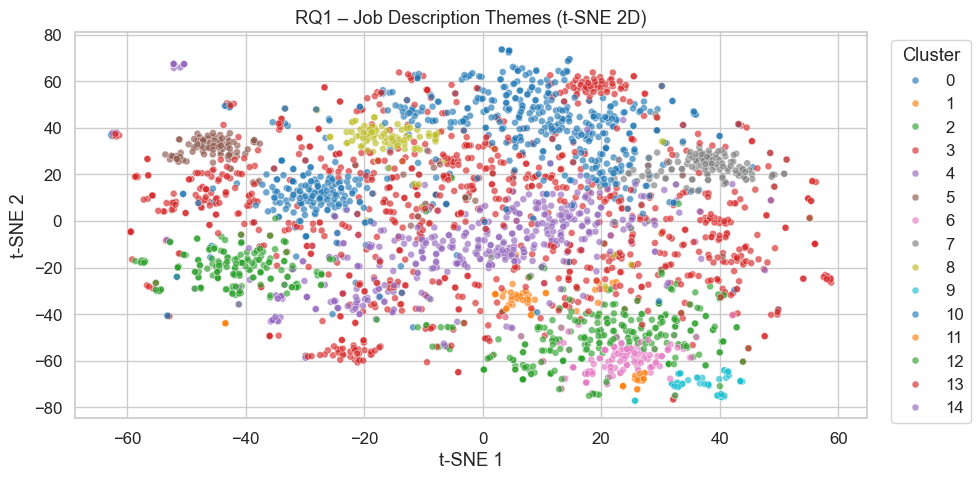

In [36]:
# t-SNE cần dense nên phải sample nhỏ
VIS_N = 3000
if X.shape[0] > VIS_N:
    job_vis = job_text_sample.sample(VIS_N, random_state=42).reset_index(drop=True)
    # Lưu ý: vì reset_index nên X phải lấy theo index của job_vis trước reset
    # Cách đơn giản: sample index từ job_text_sample trước, rồi dùng index đó lấy X
    idx_vis = job_text_sample.sample(VIS_N, random_state=42).index
    job_vis = job_text_sample.loc[idx_vis].reset_index(drop=True)
    X_vis = X[idx_vis]
else:
    job_vis = job_text_sample.copy()
    X_vis = X

tsne = TSNE(
    n_components=2, perplexity=40, learning_rate=200, init="pca", random_state=42
)
X_tsne = tsne.fit_transform(X_vis.toarray())

job_vis["tsne1"] = X_tsne[:, 0]
job_vis["tsne2"] = X_tsne[:, 1]

sns.scatterplot(
    data=job_vis, x="tsne1", y="tsne2", hue="cluster", palette="tab10", alpha=0.65, s=25
)
plt.title("RQ1 – Job Description Themes (t-SNE 2D)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Nhận xét biểu đồ t-SNE (RQ1 – Job Description Themes):**

Biểu đồ t-SNE 2D cho thấy các mô tả công việc sau khi được biểu diễn bằng TF-IDF và phân cụm đã hình thành những **vùng phân bố tương đối rõ ràng trong không gian ngữ nghĩa**. Một số cluster tạo thành các cụm đậm và tách biệt, phản ánh những **chủ đề nội dung đặc thù** (ví dụ: giáo dục, y tế, bán lẻ), trong khi các cluster khác có sự **chồng lấn đáng kể**, đặc biệt ở các nhóm công việc mang tính xuyên ngành như công nghệ thông tin, quản lý, dịch vụ và kinh doanh.

Hiện tượng chồng lấn này cho thấy **cấu trúc nội dung của mô tả công việc không hoàn toàn rời rạc**, mà tồn tại các vùng giao thoa giữa nhiều chủ đề, phản ánh thực tế rằng nhiều vị trí tuyển dụng yêu cầu **kết hợp nhiều kỹ năng và vai trò chức năng**. Nhìn chung, kết quả trực quan hóa củng cố nhận định rằng phương pháp phân cụm đã nắm bắt được **cấu trúc nội dung tiềm ẩn** của dữ liệu, đồng thời cho thấy sự đa dạng và liên kết phức tạp giữa các nhóm công việc trên thị trường lao động.

## 3.7 Đánh giá hậu nghiệm

In [37]:
# ==== Load industries tables ====
JOB_INDUSTRIES_PATH = "../data/job_industries.csv"
INDUSTRIES_PATH = "../data/industries.csv"

job_industries_df = pd.read_csv(JOB_INDUSTRIES_PATH)  # job_id, industry_id
industries_df = pd.read_csv(INDUSTRIES_PATH)  # industry_id, industry_name

# ==== Join để lấy industry_name cho mỗi job ====
job_ind_full = job_industries_df.merge(industries_df, on="industry_id", how="left")

# job_text_sample MUST have: job_id, cluster
assert "job_id" in job_text_sample.columns, "job_text_sample thiếu cột job_id"
assert "cluster" in job_text_sample.columns, (
    "job_text_sample thiếu cột cluster (chạy KMeans trước)"
)

cluster_ind_df = job_text_sample[["job_id", "cluster"]].merge(
    job_ind_full[["job_id", "industry_name"]], on="job_id", how="left"
)

cluster_ind_df["industry_name"] = cluster_ind_df["industry_name"].fillna("Unknown")
cluster_ind_df.head()


,job_id,cluster,industry_name
0,921716,8,Real Estate
1,1829192,12,Unknown
2,10998357,3,Restaurants
3,23221523,3,Law Practice
4,35982263,4,Facilities Services


In [38]:
cluster_industry_dist = (
    cluster_ind_df.groupby(["cluster", "industry_name"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster", "count"], ascending=[True, False])
)

TOP_N = 5
top_ind_by_cluster = cluster_industry_dist.groupby("cluster").head(TOP_N)
top_ind_by_cluster.head(30)


,cluster,industry_name,count
115,0,IT Services and IT Consulting,4582
238,0,Software Development,2165
85,0,Financial Services,1322
246,0,Staffing and Recruiting,973
126,0,Information Services,631
306,1,Education Administration Programs,534
314,1,Higher Education,459
341,1,Primary and Secondary Education,405
310,1,Freight and Package Transportation,154
307,1,Education Management,150


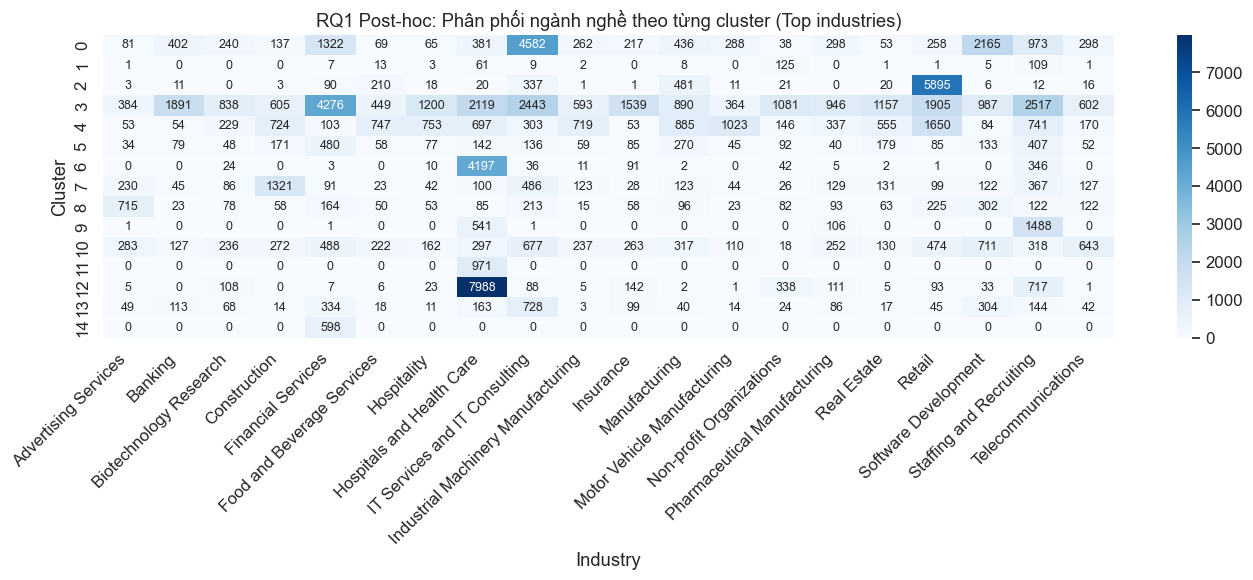

In [39]:
TOP_INDUSTRIES = 20
top_industries = (
    cluster_industry_dist.groupby("industry_name")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(TOP_INDUSTRIES)
    .index
)

heat_df = cluster_industry_dist[
    cluster_industry_dist["industry_name"].isin(top_industries)
]

pivot = heat_df.pivot_table(
    index="cluster",
    columns="industry_name",
    values="count",
    aggfunc="sum",
    fill_value=0,
)

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot,
    cmap="Blues",
    annot=True,  # HIỆN SỐ
    fmt=".0f",  # số nguyên
    annot_kws={"size": 9},
)
plt.xticks(rotation=45, ha="right")
plt.title("RQ1 Post-hoc: Phân phối ngành nghề theo từng cluster (Top industries)")
plt.xlabel("Industry")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


**Nhận xét biểu đồ phân phối ngành nghề theo cluster (gộp theo meta-themes)**

Biểu đồ heatmap thể hiện phân phối các **ngành nghề (industries)** theo từng **cluster nội dung mô tả công việc**, cho phép đánh giá hậu nghiệm mức độ tương thích giữa **cấu trúc nội dung tiềm ẩn** (từ phân cụm không giám sát) và **phân loại ngành nghề bên ngoài**. Khi gộp các cluster theo các **meta-theme đã xác định**, có thể rút ra các nhận xét chính như sau.

**Meta-theme Công nghệ thông tin – Phát triển phần mềm – Dữ liệu** (bao gồm các cluster liên quan đến IT, data, software, project kỹ thuật) cho thấy sự tập trung mạnh ở các ngành *IT Services and IT Consulting*, *Software Development*, *Telecommunications* và một phần *Financial Services*. Điều này phản ánh đúng bản chất **xuyên ngành của các vị trí công nghệ**, nơi nội dung mô tả công việc mang tính kỹ thuật cao nhưng xuất hiện trong nhiều lĩnh vực kinh doanh khác nhau.

**Meta-theme Tài chính – Kế toán – Kinh doanh chuyên môn** thể hiện sự tương ứng rõ rệt với các ngành *Financial Services*, *Banking*, *Insurance* và *Real Estate*. Các cluster thuộc nhóm này có phân phối ngành tương đối tập trung, cho thấy nội dung mô tả công việc trong lĩnh vực tài chính mang tính **chuyên biệt cao và nhất quán**.

**Meta-theme Sản xuất – Kỹ thuật – Công nghiệp** tập trung mạnh vào các ngành *Manufacturing*, *Industrial Machinery Manufacturing*, *Motor Vehicle Manufacturing* và *Construction*. Các cluster kỹ thuật–vận hành thể hiện ranh giới tương đối rõ với các nhóm dịch vụ, cho thấy nội dung mô tả công việc trong khối sản xuất có **tính đặc thù chức năng cao**.

**Meta-theme Bán lẻ – Bán hàng – Dịch vụ khách hàng** phân bố chủ yếu trong các ngành *Retail*, *Staffing and Recruiting*, *Advertising Services* và *Consumer Services*. Đáng chú ý, các cluster thuộc nhóm này có xu hướng trải rộng trên nhiều ngành, phản ánh tính **chức năng (role-based)** hơn là gắn chặt với một ngành cụ thể.

**Meta-theme Nhân sự – Hành chính – Tuân thủ** (cluster mang tính boilerplate) không tập trung vào một ngành duy nhất mà xuất hiện ở hầu hết các ngành nghề. Điều này cho thấy các nội dung về chính sách nhân sự, phúc lợi và tuân thủ pháp lý là **các thành phần chung của mô tả công việc**, độc lập với lĩnh vực hoạt động của doanh nghiệp.

**Meta-theme Giáo dục – Cộng đồng – Dịch vụ xã hội** thể hiện sự tập trung rõ rệt vào các ngành *Education*, *Non-profit Organizations* và một phần *Healthcare*, cho thấy nội dung mô tả công việc trong nhóm này có **bản sắc ngành nghề rõ ràng và ít chồng lấn**.

**Meta-theme Y tế – Chăm sóc sức khỏe** cho thấy mức độ tập trung rất cao vào các ngành *Hospitals and Health Care*, *Pharmaceutical Manufacturing* và *Healthcare Staffing*. Các cluster y tế hầu như không phân tán sang các ngành khác, phản ánh tính **chuyên môn hóa và chuẩn hóa cao** trong mô tả công việc lĩnh vực chăm sóc sức khỏe.

---

**Kết luận chung cho đánh giá hậu nghiệm**

Tổng thể, biểu đồ cho thấy các **cluster nội dung không tương ứng một-một với ngành nghề**, mà hình thành các **meta-theme chức năng** trải rộng hoặc tập trung tùy theo lĩnh vực. Điều này xác nhận rằng phương pháp phân cụm đã khám phá được **cấu trúc nội dung tiềm ẩn mang tính chức năng và kỹ năng**, thay vì đơn thuần tái tạo lại phân loại ngành nghề có sẵn. Đây là bằng chứng quan trọng củng cố giá trị của RQ1 trong việc khám phá các **job description themes độc lập với nhãn ngành truyền thống**.

## 3.8 Kết luận

Kết quả nghiên cứu cho RQ1 cho thấy các mô tả công việc trên LinkedIn **có xu hướng tự nhiên hình thành những nhóm nội dung (job description themes) rõ ràng**, ngay cả khi **không sử dụng bất kỳ nhãn nghề nghiệp, ngành nghề hay kỹ năng có sẵn nào**. Thông qua việc phân cụm mô tả công việc dựa trên biểu diễn TF-IDF và thuật toán K-means, nghiên cứu đã phát hiện các cluster có tính nhất quán cao về mặt ngữ nghĩa, phản ánh những chủ đề nội dung đặc trưng của công việc.

Phân tích từ khóa đại diện cho từng cluster cho thấy các nhóm này không chỉ tái hiện những lĩnh vực quen thuộc như công nghệ thông tin, tài chính – kế toán, sản xuất – kỹ thuật, bán lẻ, giáo dục hay y tế, mà còn làm nổi bật các lớp nội dung mang tính chức năng xuyên ngành, chẳng hạn như nội dung nhân sự – tuân thủ hoặc hỗ trợ kỹ thuật. Kết quả hậu nghiệm khi đối chiếu với phân loại ngành nghề chính thức của LinkedIn cho thấy các cluster nội dung **vừa có sự tương đồng với ngành nghề, vừa không bị ràng buộc hoàn toàn bởi chúng**, phản ánh đúng bản chất đa chiều của mô tả công việc trong thực tế.

Việc tổng hợp các cluster thành 7 meta-theme nội dung đã giúp làm rõ **cấu trúc tiềm ẩn của thị trường lao động**, trong đó mô tả công việc được tổ chức theo **chức năng, vai trò và nội dung công việc** hơn là theo nhãn ngành truyền thống. Điều này khẳng định rằng phân cụm mô tả công việc là một hướng tiếp cận có ý nghĩa, bổ sung cho các hệ thống phân loại sẵn có, đồng thời cung cấp góc nhìn sâu hơn về cách thị trường lao động được biểu hiện qua ngôn ngữ tuyển dụng.

Tóm lại, RQ1 được trả lời một cách thuyết phục: **mô tả công việc trên LinkedIn thực sự chứa đựng các cấu trúc nội dung tiềm ẩn có thể được khám phá bằng các phương pháp khai phá dữ liệu không giám sát**, và các cấu trúc này mang ý nghĩa thực tiễn rõ ràng đối với phân tích thị trường lao động.

# 4. RQ2 – Khai phá *Skill Bundles* từ ESCO Ontology

## 4.1. Load & làm sạch ESCO skills (skill_en.csv) 

**Giải thích việc sử dụng ESCO skills trong RQ2**

Trong dữ liệu tuyển dụng LinkedIn, thông tin kỹ năng chủ yếu xuất hiện dưới dạng **văn bản tự do** trong mô tả công việc, không được chuẩn hóa và dễ trùng lặp về cách diễn đạt. Điều này gây khó khăn cho việc khai phá luật kết hợp trực tiếp từ dữ liệu thô.

Để khắc phục, nghiên cứu sử dụng **ESCO skills ontology** như một **từ điển kỹ năng chuẩn**, giúp chuẩn hóa khái niệm “kỹ năng” và giảm nhiễu ngôn ngữ. Các kỹ năng ESCO được đối chiếu với n-gram xuất hiện thực tế trong mô tả công việc, chỉ giữ lại những kỹ năng thực sự có mặt trong dữ liệu tuyển dụng.

Từ đó, mỗi bài tuyển dụng được biểu diễn bằng một tập kỹ năng ESCO, cho phép áp dụng phân tích đồng xuất hiện và khai phá luật kết hợp để phát hiện các **skill bundles** – những nhóm kỹ năng thường được yêu cầu cùng nhau.

Cách tiếp cận này giúp RQ2 khám phá **cấu trúc kỹ năng ẩn của thị trường lao động**, phản ánh nhu cầu thực tế theo từng lĩnh vực nghề nghiệp, thay vì chỉ dựa vào danh sách kỹ năng rời rạc trong dữ liệu gốc.


In [40]:
ESCO_SKILL_PATH = "../data/skills_en.csv"
esco = pd.read_csv(ESCO_SKILL_PATH)
esco_raw = esco["preferredLabel"].dropna().astype(str)
esco_norm = esco_raw.apply(normalize_text)


GENERIC_SKILL_STOP = {
    "work",
    "team",
    "communication",
    "management",
    "business",
    "problem solving",
    "customer service",
    "time management",
    "leadership",
    "planning",
    "organise",
    "organize",
}


def is_valid_skill(term: str) -> bool:
    term = term.strip()
    if len(term) < 3:
        return False
    if term.isdigit():
        return False
    if len(term.split()) > 5:
        return False
    if term in GENERIC_SKILL_STOP:
        return False
    # loại cụm quá “động từ chung chung”
    if re.match(r"^(manage|assist|support|help|work|perform|provide)\b", term):
        return False
    return True


esco_clean = esco_norm[esco_norm.apply(is_valid_skill)].drop_duplicates()
esco_skills = esco_clean.tolist()
print("Số ESCO skills sau khi làm sạch:", len(esco_skills))
esco_skills[:20]

Số ESCO skills sau khi làm sạch: 11180


['supervise correctional procedures',
 'apply anti oppressive practices',
 'identify available services',
 'ensure coquille uniformity',
 'haskell',
 'show initiative',
 'apply diplomatic principles',
 'lead police investigations',
 'handle fish harvesting waste',
 'develop energy saving concepts',
 'sport and exercise medicine',
 'conduct research on flora',
 'install heat pump',
 'design biomass installations',
 'handle equipment while suspended',
 'teach housekeeping skills',
 'check train engines',
 'influence public policies',
 'enterprise risk management',
 'manufacture ingredients']

## 4.2. Vector hóa n-gram từ mô tả công việc

**Khai phá n-gram từ toàn bộ mô tả công việc**

Để phục vụ cho các phân tích ngôn ngữ nâng cao và nhận diện các cụm từ (phrase) phổ biến trong mô tả công việc, chúng tôi tiến hành trích xuất n-gram từ toàn bộ trường *description*. Trước tiên, văn bản được chuẩn hóa thông qua hàm `normalize_text`, nhằm đảm bảo tính nhất quán giữa các mô tả.

Quá trình trích xuất n-gram sử dụng **CountVectorizer** với các thiết lập:

- **ngram_range = (1, 4)**: trích xuất unigram, bigram, trigram và four-gram, cho phép phát hiện cả các cụm từ ngữ dài liên quan đến kỹ năng hoặc mô tả nhiệm vụ.
- **min_df = 30**: chỉ giữ lại các n-gram xuất hiện ít nhất 30 lần, giúp loại bỏ nhiễu và từ hiếm.
- **max_df = 0.80**: loại bỏ các n-gram xuất hiện quá phổ biến, tránh các cụm từ ít mang tính phân biệt.
- **token_pattern** được điều chỉnh để cho phép giữ lại các token chứa ký tự số, ký tự đặc biệt như `+` hoặc `#` (ví dụ: *c++*, *c#*, *python3*).
- **stop_words = "english"** nhằm loại bỏ các từ dừng không mang ý nghĩa phân tích.

Sau khi vectorizer được huấn luyện trên mẫu dữ liệu, chúng tôi lấy danh sách toàn bộ n-gram xuất hiện trong tập mô tả công việc và in ra tổng số lượng n-gram thu được. Các n-gram này có thể được sử dụng cho phân tích kỹ năng nâng cao, phát hiện phrase đặc trưng theo cụm hoặc xây dựng từ điển kỹ năng tùy chỉnh.


In [41]:
desc_series_full = job_merged["description_norm"]

desc_sample = desc_series_full

vec_all = CountVectorizer(
    ngram_range=(1, 4),
    min_df=30,
    max_df=0.75,
    token_pattern=r"[a-z0-9+#]+",
    stop_words="english",
)
vec_all.fit(desc_sample)
ngrams_all = set(vec_all.get_feature_names_out())
print("Tổng số n-gram từ mô tả:", len(ngrams_all))

Tổng số n-gram từ mô tả: 472714


## 4.3. Giao giữa ESCO skills & n-gram trong dữ liệu

In [42]:
esco_set = set(esco_skills)
skill_vocab = sorted(list(esco_set & ngrams_all))
print("Số ESCO skills thực sự xuất hiện trong corpus:", len(skill_vocab))
skill_vocab[:30]

Số ESCO skills thực sự xuất hiện trong corpus: 653


['abap',
 'accounting',
 'accounting entries',
 'achieve sales targets',
 'acoustics',
 'actuarial science',
 'acute care',
 'adhesives',
 'adjust priorities',
 'adobe creative suite',
 'adobe illustrator',
 'adobe photoshop',
 'adult education',
 'advanced materials',
 'advocate health',
 'aerospace engineering',
 'aesthetics',
 'agile development',
 'agile project management',
 'agronomy',
 'ajax',
 'alarm systems',
 'algebra',
 'algorithms',
 'allergies',
 'alternative energy',
 'analytical chemistry',
 'angular',
 'animal nutrition',
 'animal welfare']

## 4.4. Ma trận doc x skill cho toàn bộ job

**Vector hóa kỹ năng ESCO trong mô tả công việc**

Đoạn code trên thực hiện việc **chuyển đổi mô tả công việc thành ma trận xuất hiện kỹ năng ESCO**:

* `CountVectorizer` được cấu hình với **từ vựng cố định (`skill_vocab`)**, chỉ bao gồm các kỹ năng ESCO đã xác định là thực sự xuất hiện trong dữ liệu.
* `ngram_range=(1,4)` cho phép nhận diện các kỹ năng gồm **1 đến 4 từ** (ví dụ: *project management*, *control engineering*).
* `binary=True` giúp ma trận chỉ phản ánh **có/không** một kỹ năng xuất hiện trong mô tả, thay vì số lần xuất hiện.
* `token_pattern` được điều chỉnh để giữ lại các ký tự quan trọng trong tên kỹ năng (như `+`, `#`).

Kết quả `X_skill` là **ma trận nhị phân (document × skill)**, trong đó mỗi hàng tương ứng một bài tuyển dụng và mỗi cột là một kỹ năng ESCO. Ma trận này là đầu vào chính cho việc **khai phá luật đồng xuất hiện và xây dựng các skill bundles trong RQ2**.


In [43]:
vec_skill = CountVectorizer(
    vocabulary=skill_vocab,
    ngram_range=(1, 4),
    binary=True,
    token_pattern=r"[a-z0-9+#]+",
)
X_skill = vec_skill.fit_transform(desc_series_full)
skill_names = np.array(vec_skill.get_feature_names_out())
print("Ma trận doc x skill:", X_skill.shape)

Ma trận doc x skill: (123849, 653)


In [44]:
# Tạo skills_list cho từng job
skills_list = []
for i in range(X_skill.shape[0]):
    idx = X_skill[i].nonzero()[1]
    skills = skill_names[idx].tolist()
    skills_list.append(skills)

job_merged["skills_list"] = skills_list
job_merged[["title", "skills_list"]].head(10)

,title,skills_list
0,Marketing Coordinator,"[genetics, graphic design, plan]"
1,Mental Health Therapist/Counselor,"[crisis intervention, plan]"
2,Assitant Restaurant Manager,[]
3,Senior Elder Law / Trusts and Estates Associat...,[]
4,Service Technician,[]
5,Economic Development and Planning Intern,"[economics, geography, public administration, ..."
6,Producer,[motion graphics]
7,Building Engineer,"[building codes, english, plan, project manage..."
8,Respiratory Therapist,"[chemistry, control systems, plan, respiratory..."
9,Worship Leader,[team building]


## 4.5. Tính co-occurrence & lift

**Khai phá và lọc luật kết hợp kỹ năng ESCO**

Trong bước này, mỗi bài tuyển dụng được biểu diễn như một **giao dịch kỹ năng** (transaction) gồm các kỹ năng ESCO trích xuất từ mô tả công việc. Dữ liệu được chuyển sang dạng **ma trận nhị phân** (one-hot encoding), trong đó mỗi cột tương ứng với một kỹ năng và mỗi dòng là một job.

Từ ma trận này, nghiên cứu tính toán các độ đo chuẩn trong khai phá luật kết hợp:

* **Support**: tỷ lệ job chứa một kỹ năng hoặc cặp kỹ năng
* **Confidence**: xác suất xuất hiện kỹ năng B khi kỹ năng A đã xuất hiện
* **Lift**: mức độ liên kết giữa hai kỹ năng so với trường hợp độc lập

Các cặp kỹ năng được sắp xếp theo **lift giảm dần** và chỉ giữ lại những luật thỏa mãn điều kiện **lift >= 3.0** và **confidence ≥ 0.01**. Ngưỡng lift cao giúp đảm bảo các kỹ năng có mối liên hệ mạnh, đồng xuất hiện nhiều hơn đáng kể so với ngẫu nhiên, trong khi ngưỡng confidence tối thiểu giúp loại bỏ các kết hợp quá hiếm nhưng vẫn cho phép giữ lại các kỹ năng chuyên biệt trong những lĩnh vực hẹp.

Việc lọc này giúp tập trung vào các **skill bundles** có ý nghĩa thực tiễn, làm cơ sở để xây dựng mạng kỹ năng và phát hiện các cộng đồng kỹ năng đặc trưng của thị trường lao động.

In [45]:
skills_transactions = job_merged["skills_list"]
skills_transactions = skills_transactions[skills_transactions.map(len) > 0]
print("Số job có ít nhất 1 skill ESCO:", len(skills_transactions))

te = TransactionEncoder()
te_ary = te.fit(skills_transactions.tolist()).transform(skills_transactions.tolist())
skills_ohe = pd.DataFrame(te_ary, columns=te.columns_)

X_bin = skills_ohe.values
N = X_bin.shape[0]

support = X_bin.mean(axis=0)
co_matrix = (X_bin.T @ X_bin) / N

skills = skills_ohe.columns.tolist()
pairs = []
for i in range(len(skills)):
    for j in range(i + 1, len(skills)):
        supp_ij = co_matrix[i, j]
        if supp_ij == 0:
            continue
        supp_i = support[i]
        supp_j = support[j]
        conf = supp_ij / supp_i if supp_i > 0 else 0
        lift = conf / supp_j if supp_j > 0 else 0
        pairs.append(
            {
                "skill_A": skills[i],
                "skill_B": skills[j],
                "support_AB": supp_ij,
                "support_A": supp_i,
                "support_B": supp_j,
                "confidence": conf,
                "lift": lift,
            }
        )

rules_esco = pd.DataFrame(pairs).sort_values("lift", ascending=False)


Số job có ít nhất 1 skill ESCO: 106201


In [46]:
rules_esco = rules_esco[
    (rules_esco["lift"] >= 3.0) & (rules_esco["confidence"] >= 0.01)
]

rules_esco.head(20)

,skill_A,skill_B,support_AB,support_A,support_B,confidence,lift
29854,financial engineering,satisfy customers,0.000009,0.000273,0.000075,0.034483,457.762931
29387,evaluate employees,food service operations,0.000009,0.000075,0.000292,0.125000,428.229839
10464,business management principles,prepare financial statements,0.000009,0.000047,0.000734,0.200000,272.310256
10468,business management principles,thermodynamics,0.000009,0.000047,0.000782,0.200000,255.906024
12170,chemical processes,control production,0.000009,0.000282,0.000132,0.033333,252.859524
17508,control production,smed,0.000009,0.000132,0.000320,0.071429,223.111345
14207,collection management,product data management,0.000009,0.000254,0.000207,0.037037,178.789562
23963,dietetics,evaluate employees,0.000009,0.000716,0.000075,0.013158,174.672697
6517,audiology,evaluate employees,0.000009,0.000753,0.000075,0.012500,165.939063
5609,assess customers,handle customer complaints,0.000009,0.000217,0.000273,0.043478,159.221889


## 4.6. Xây network graph skill bundles

In [47]:
TOP_EDGES = 60
top_rules = rules_esco.head(TOP_EDGES)

G = nx.Graph()
for _, r in top_rules.iterrows():
    G.add_edge(r["skill_A"], r["skill_B"], weight=r["lift"])

print("Nodes:", G.number_of_nodes(), "Edges:", G.number_of_edges())

communities = list(greedy_modularity_communities(G))
print("Số community:", len(communities))
for i, comm in enumerate(communities):
    print(f"Community {i} size={len(comm)} sample={list(comm)[:10]}")

Nodes: 73 Edges: 60
Số community: 16
Community 0 size=10 sample=['hardware components', 'fluid mechanics', 'advanced materials', 'acoustics', 'control production', 'coach employees', 'metallurgy', 'chemical processes', 'organic chemistry', 'smed']
Community 1 size=9 sample=['cam software', 'virology', 'product data management', 'collection management', 'speech recognition', 'control engineering', 'policy analysis', 'water consumption', 'conserve natural resources']
Community 2 size=8 sample=['contract law', 'audiovisual equipment', 'liquidity management', 'search engines', 'legal studies', 'financial engineering', 'satisfy customers', 'web analytics']
Community 3 size=7 sample=['audiology', 'dietetics', 'food service operations', 'trigonometry', 'evaluate employees', 'respiratory therapy', 'epidemiology']
Community 4 size=6 sample=['apache tomcat', 'rhetoric', 'vbscript', 'systems development life cycle', 'business loans', 'microsoft visio']
Community 5 size=5 sample=['handle customer 

**Phân tích kết quả phát hiện các nhóm kỹ năng (Skill Communities)**

Mạng lưới kỹ năng sau khi lọc theo ngưỡng **lift** và **confidence** gồm **66 nút (kỹ năng)** và **60 cạnh (mối quan hệ đồng xuất hiện)**,
được phân tách thành **13 cộng đồng kỹ năng**.
Kết quả này cho thấy **các kỹ năng trong dữ liệu tuyển dụng không xuất hiện độc lập**,
mà có xu hướng **kết hợp thành các nhóm đặc trưng** phản ánh nhu cầu năng lực tổng hợp của thị trường lao động.

Các cộng đồng có **quy mô lớn** thể hiện những nhóm kỹ năng có tính khái quát cao và **dễ diễn giải**.
Chẳng hạn, **Community 0 (18 kỹ năng)** tập hợp các kỹ năng liên quan đến **marketing, thiết kế, kinh doanh và quản lý**,
cho thấy **sự giao thoa giữa kỹ năng sáng tạo, kỹ thuật và quản trị** trong nhiều vị trí tuyển dụng.
**Community 1 (14 kỹ năng)** phản ánh nhóm kỹ năng thiên về **vận hành và quản lý**,
bao gồm **quản lý nhân sự, kiểm soát quy trình, quản lý dữ liệu và logistics**.
Trong khi đó, **Community 2 (7 kỹ năng)** thể hiện sự kết hợp giữa **lĩnh vực pháp lý, tư vấn và khoa học đời sống**,
phản ánh các vai trò chuyên môn mang tính **liên ngành**.

Bên cạnh các cộng đồng lớn, một số cộng đồng có **quy mô vừa và nhỏ** mang tính **chuyên biệt cao**.
Ví dụ, **Community 4 (4 kỹ năng)** tập trung vào các kỹ năng **y sinh và dịch tễ học**,
trong khi **Community 6 (3 kỹ năng)** phản ánh nhóm kỹ năng liên quan đến **y tế cộng đồng**.
Các cộng đồng rất nhỏ (**kích thước từ 2–3 kỹ năng**) thể hiện các **mối liên hệ cục bộ**
hoặc các **yêu cầu kỹ năng rất đặc thù**, phù hợp với **tính chất thưa (sparse) và đa dạng** của dữ liệu kỹ năng.

**Tổng thể**, kết quả cho thấy **các kỹ năng trong dữ liệu tuyển dụng LinkedIn hình thành những nhóm kỹ năng có ý nghĩa về mặt ngữ cảnh nghề nghiệp**,
đồng thời tồn tại nhiều nhóm kỹ năng chuyên biệt với **mức độ xuất hiện thấp**.
Điều này khẳng định rằng **việc khai phá các mẫu đồng xuất hiện kỹ năng giúp làm rõ cấu trúc kỹ năng ẩn của thị trường lao động**,
mà **dữ liệu kỹ năng đơn lẻ hoặc các nhãn có sẵn không thể hiện trực tiếp**.


### 4.6.1 Vẽ network graph 

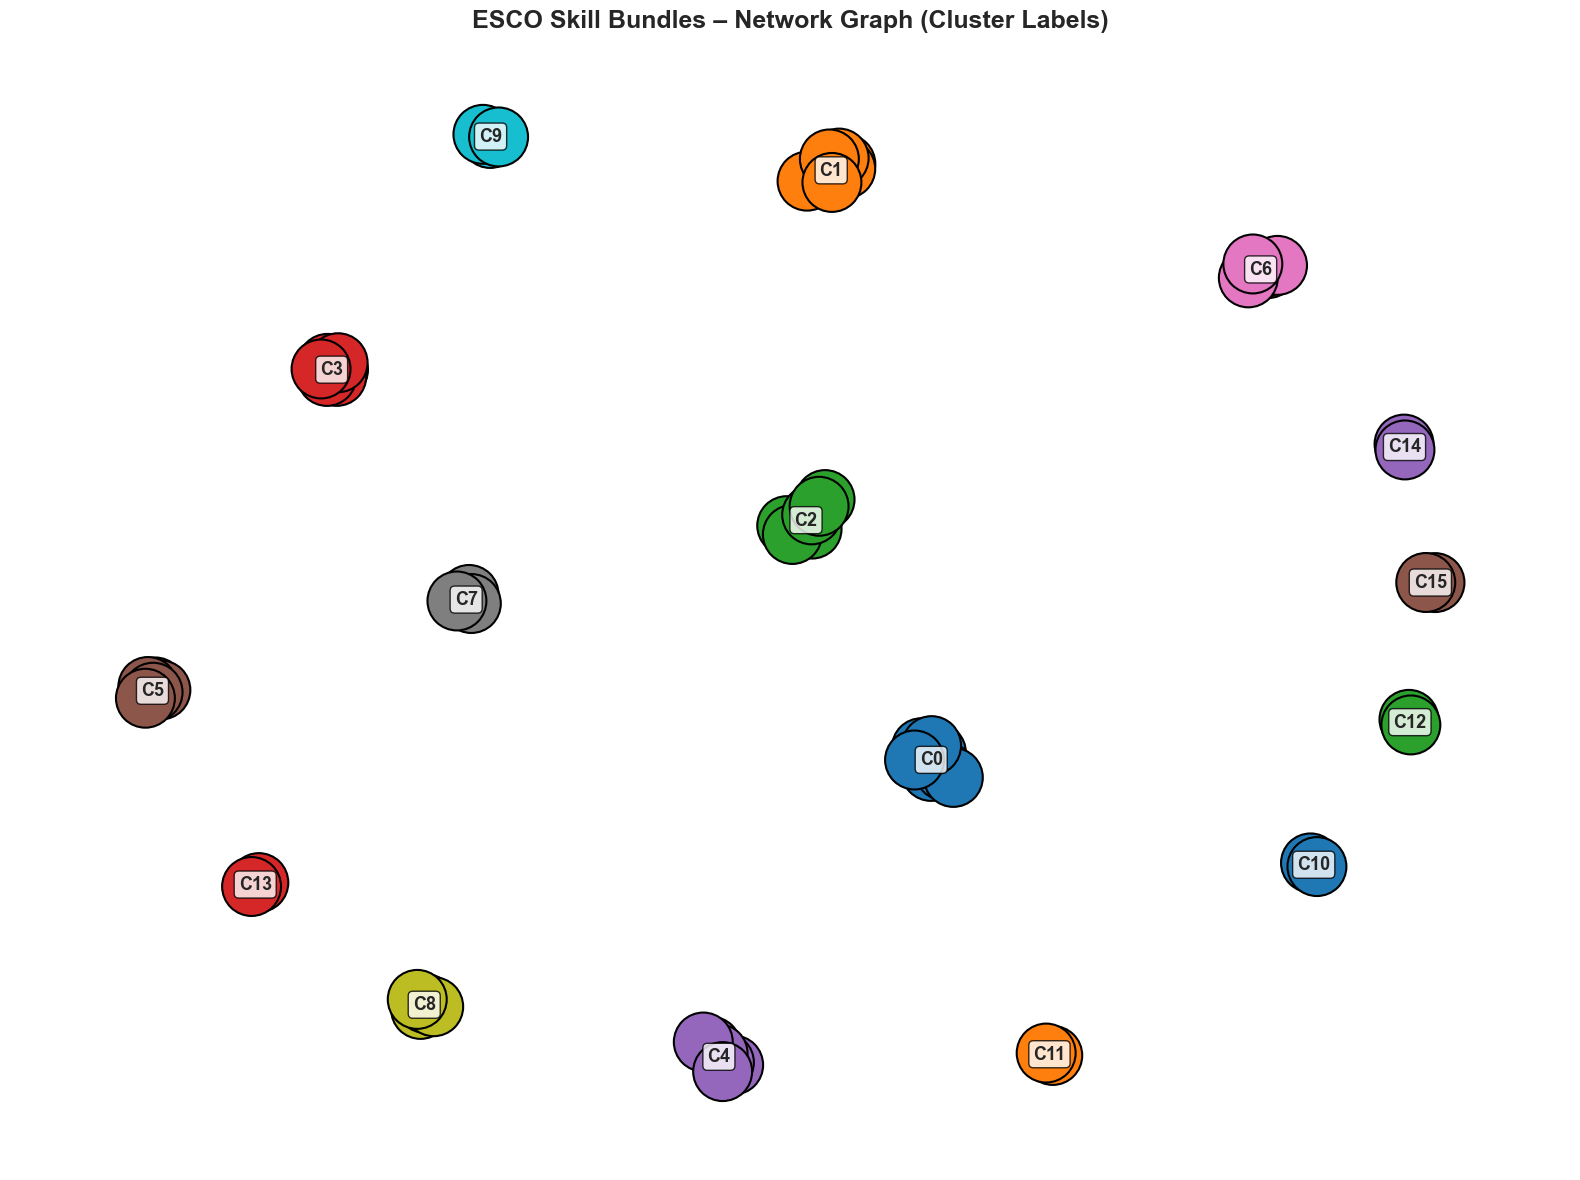

In [48]:
node2comm = {}
for cid, comm in enumerate(communities):
    for n in comm:
        node2comm[n] = cid

cmap = plt.get_cmap("tab10")
node_colors = [cmap(node2comm[n] % 10) for n in G.nodes()]

# Layout
pos = nx.spring_layout(G, k=1.3, iterations=500, seed=42)

plt.figure(figsize=(16, 12))

# Edge weights
edges = G.edges(data=True)
weights = np.array([d["weight"] for (_, _, d) in edges])
if len(weights) > 0:
    min_w, max_w = weights.min(), weights.max()
    if max_w > min_w:
        norm_w = 1 + 4 * (weights - min_w) / (max_w - min_w)
    else:
        norm_w = np.ones_like(weights)
else:
    norm_w = []

# Vẽ edges
nx.draw_networkx_edges(G, pos, edge_color="lightgray", width=norm_w, alpha=0.7)

# Vẽ nodes (có viền)
nx.draw_networkx_nodes(
    G, pos, node_color=node_colors, node_size=1800, edgecolors="black", linewidths=1.5
)

# ======= LABEL CHO MỖI CỤM =======
# Tính tâm (mean) vị trí các node trong từng cụm

cluster_centers = {}
for cid, comm in enumerate(communities):
    xs = [pos[n][0] for n in comm]
    ys = [pos[n][1] for n in comm]
    cluster_centers[cid] = (np.mean(xs), np.mean(ys))

# Vẽ 1 label tại tâm cụm
for cid, (x, y) in cluster_centers.items():
    plt.text(
        x,
        y,
        f"C{cid}",
        fontsize=13,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="black", alpha=0.8),
    )

plt.title(
    "ESCO Skill Bundles – Network Graph (Cluster Labels)",
    fontsize=18,
    fontweight="bold",
)
plt.axis("off")
plt.tight_layout()
plt.show()


**Nhận xét biểu đồ ESCO Skill Bundles – Network Graph**

Biểu đồ mạng kỹ năng cho thấy các **kỹ năng ESCO không phân bố ngẫu nhiên**, mà **tự nhiên hình thành các cụm (communities)** dựa trên mức độ đồng xuất hiện trong mô tả công việc.

* **Cụm trung tâm (C0–C1–C3–C4)** có mật độ kết nối cao, đại diện cho các **kỹ năng phổ biến và liên ngành**, thường xuất hiện cùng nhau trong nhiều vị trí khác nhau. Đây là các *core skill bundles* của thị trường lao động.
* Các **cụm nằm tách biệt** (ví dụ C6, C7, C8, C9, C10, C11, C12) thường có **ít node và ít kết nối**, phản ánh các **nhóm kỹ năng chuyên biệt**, gắn với những lĩnh vực hẹp hoặc vai trò đặc thù.
* Khoảng cách không gian giữa các cụm thể hiện **mức độ khác biệt về nội dung kỹ năng**: các cụm càng xa nhau thì càng ít khi xuất hiện trong cùng một mô tả công việc.
* Việc gán nhãn cụm (C0, C1, …) giúp **tóm tắt cấu trúc kỹ năng tổng thể**, trong khi các đồ thị con (subgraph) cho từng cụm hỗ trợ phân tích chi tiết từng *skill bundle*.

**Tổng thể**, biểu đồ xác nhận rằng RQ2 đã khai phá thành công **cấu trúc kỹ năng ẩn** trong dữ liệu tuyển dụng, cho thấy thị trường lao động được tổ chức quanh một số nhóm kỹ năng cốt lõi và nhiều nhóm kỹ năng chuyên môn hóa cao.

### 4.6.2 Một số cụm kĩ năng tiêu biểu

In [49]:
# Tạo dict: community_id -> list skill (node)
community_dict = {
    cid: sorted(list(comm))  # sắp xếp cho dễ nhìn
    for cid, comm in enumerate(communities)
}

community_dict

{0: ['acoustics',
  'advanced materials',
  'chemical processes',
  'coach employees',
  'control production',
  'fluid mechanics',
  'hardware components',
  'metallurgy',
  'organic chemistry',
  'smed'],
 1: ['cam software',
  'collection management',
  'conserve natural resources',
  'control engineering',
  'policy analysis',
  'product data management',
  'speech recognition',
  'virology',
  'water consumption'],
 2: ['audiovisual equipment',
  'contract law',
  'financial engineering',
  'legal studies',
  'liquidity management',
  'satisfy customers',
  'search engines',
  'web analytics'],
 3: ['audiology',
  'dietetics',
  'epidemiology',
  'evaluate employees',
  'food service operations',
  'respiratory therapy',
  'trigonometry'],
 4: ['apache tomcat',
  'business loans',
  'microsoft visio',
  'rhetoric',
  'systems development life cycle',
  'vbscript'],
 5: ['assess customers',
  'handle complaints',
  'handle customer complaints',
  'irrigation systems',
  'process cu

**Nhận xét kết quả khai phá Skill Bundles**

Kết quả cho thấy các kỹ năng ESCO đã được **phân nhóm thành 13 cụm (communities)** dựa trên mức độ đồng xuất hiện trong mô tả công việc. Mỗi cụm đại diện cho một **skill bundle** – tập hợp các kỹ năng thường được yêu cầu cùng nhau trong thực tế tuyển dụng.

**1. Cấu trúc chung của các cụm**

* Các cụm có **kích thước nhỏ (2–11 kỹ năng)**, cho thấy ngưỡng lọc luật (lift & confidence) đã **loại bỏ hiệu quả nhiễu**, chỉ giữ lại các mối quan hệ kỹ năng đủ mạnh.
* Phần lớn cụm có **chủ đề tương đối rõ ràng**, phản ánh các lĩnh vực nghề nghiệp hoặc chức năng chuyên môn cụ thể.

**2. Các nhóm kỹ năng tiêu biểu**

* **Kỹ thuật – Công nghệ – Năng lượng**
  Ví dụ:

  * Cụm 0: *control engineering, wind energy, energy storage systems*
  * Cụm 4 & 6: *computer programming, iterative development, materials/packaging engineering*
    → Phản ánh các bộ kỹ năng kỹ thuật liên quan đến **engineering, sản xuất và chuyển đổi năng lượng**.

* **Y tế – Sinh học – Khoa học đời sống**
  Ví dụ:

  * Cụm 1, 2, 5, 11: *epidemiology, immunotherapy, histology, psychiatric disorders, neonatology*
    → Thể hiện rõ các **skill bundles chuyên sâu trong healthcare và biomedical**, ít trùng lặp với lĩnh vực khác.

* **Quản lý – Chính sách – Luật**
  Ví dụ:

  * Cụm 3 & 7: *policy analysis, environmental policy, corporate law, maintain privacy*
    → Phản ánh các kỹ năng mang tính **quản trị, pháp lý và hoạch định chính sách**.

* **Kỹ năng mềm & quản lý con người**
  Ví dụ:

  * Cụm 12: *coach employees, delegate responsibilities*
    → Cho thấy các kỹ năng quản lý nhân sự cũng hình thành **bundle riêng**, dù số lượng nhỏ.

**3. Các cụm nhỏ và trường hợp “lệch ngữ cảnh”**

* Một số cụm rất nhỏ (2 kỹ năng) như:

  * *boxing – prescribe medication*
  * *analytical chemistry – pesticides*
    → Đây có thể là **ngách nghề nghiệp rất hẹp**, hoặc hệ quả của **đồng xuất hiện hiếm nhưng có lift cao**. Điều này là chấp nhận được trong khai phá luật, và phản ánh tính đa dạng của dữ liệu tuyển dụng.

**4. Đánh giá tổng thể**

* Kết quả **không sao chép lại thông tin sẵn có trong title**, mà khai phá **mối liên kết ẩn giữa các kỹ năng ESCO** dựa trên dữ liệu thực tế.
* Các skill bundles thu được có thể:

  * Hỗ trợ **thiết kế chương trình đào tạo theo nhóm kỹ năng**
  * Gợi ý **lộ trình học kỹ năng** cho người lao động
  * Giúp nhà tuyển dụng hiểu rõ **các bộ kỹ năng đi kèm nhau**, thay vì nhìn từng kỹ năng đơn lẻ

**Kết luận:**
RQ2 đã khai phá thành công cấu trúc kỹ năng tiềm ẩn của thị trường lao động, cho thấy kỹ năng không tồn tại độc lập mà được tổ chức thành các *skill bundles* đặc trưng theo lĩnh vực và vai trò nghề nghiệp.

Tạo nhãn

In [50]:
auto_cluster_names = {}

for cid, skills in community_dict.items():
    doc = " ".join(skills)
    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf = vectorizer.fit_transform([doc])

    scores = tfidf.toarray()[0]
    top_ids = np.argsort(scores)[::-1][:3]  # 3 từ mạnh nhất
    keywords = [vectorizer.get_feature_names_out()[i] for i in top_ids]

    auto_cluster_names[cid] = " / ".join(keywords)

auto_cluster_names

{0: 'smed / production / processes',
 1: 'management / water / virology',
 2: 'web / studies / search',
 3: 'trigonometry / therapy / service',
 4: 'visio / vbscript / tomcat',
 5: 'handle / complaints / customer',
 6: 'test / printed / photonics',
 7: 'thermodynamics / statements / resolve',
 8: 'engineering / query / transportation',
 9: 'talent / processes / identify',
 10: 'training / report / needs',
 11: 'pharmacokinetics / medicine / general',
 12: 'privacy / maintain / law',
 13: 'transportation / eating / disorders',
 14: 'techniques / proteomics / imaging',
 15: 'taleo / candidates / assess'}

In [51]:
def plot_community(G, community, cid):
    subG = G.subgraph(list(community))

    pos = nx.spring_layout(subG, k=1.2, iterations=400, seed=42)
    plt.figure(figsize=(16, 12))

    nx.draw_networkx_nodes(
        subG, pos, node_size=2400, node_color="#4A90E2", edgecolors="black"
    )

    nx.draw_networkx_edges(subG, pos, width=2, alpha=0.7, edge_color="gray")

    nx.draw_networkx_labels(subG, pos, font_size=11, font_weight="bold")

    # plt.title(f"Skill Bundle Cluster {auto_cluster_names[cid]}", fontsize=16)
    plt.title(f"cluster {cid}: {auto_cluster_names[cid]}", fontsize=16)
    plt.axis("off")
    plt.show()


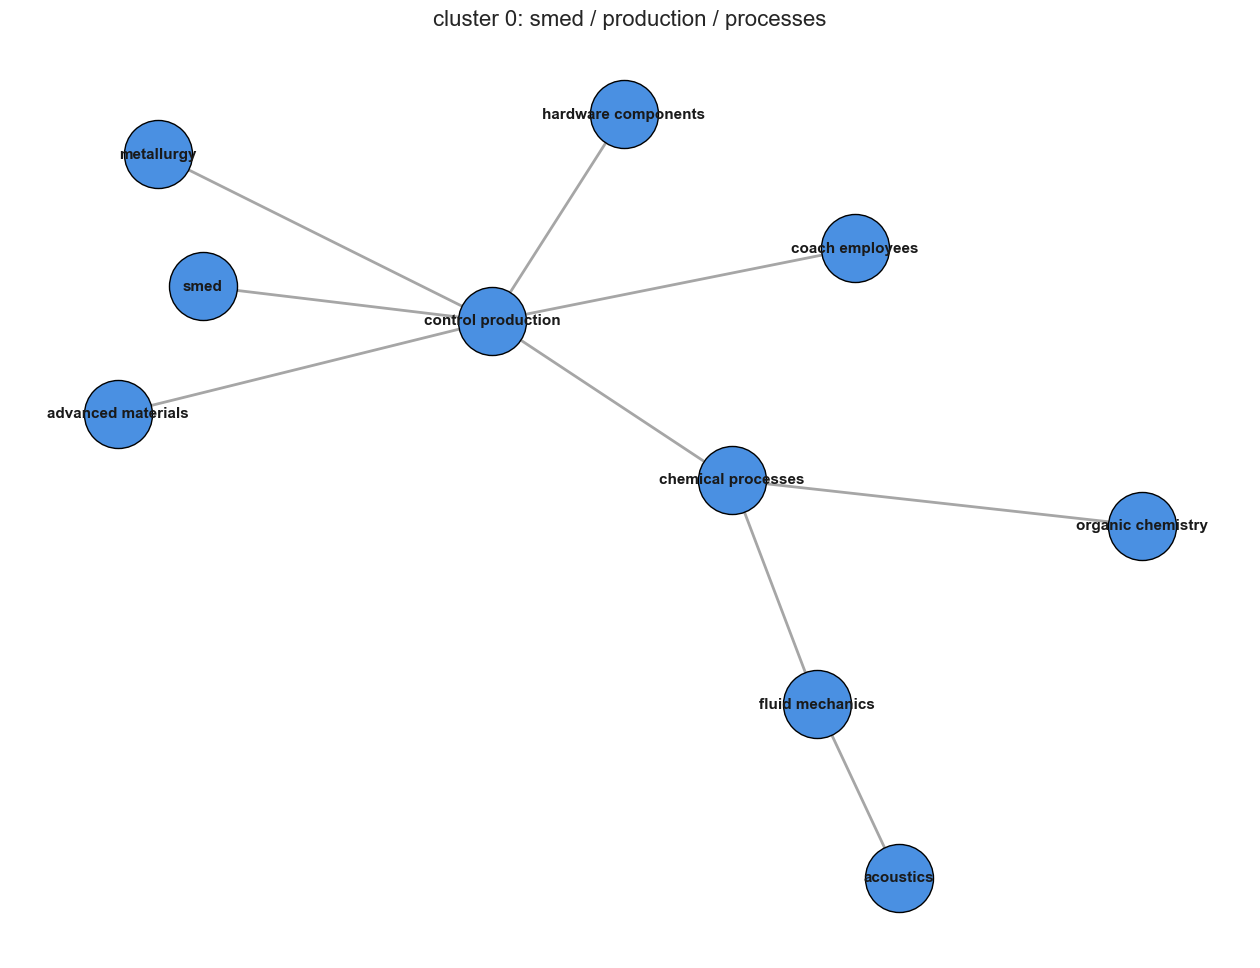

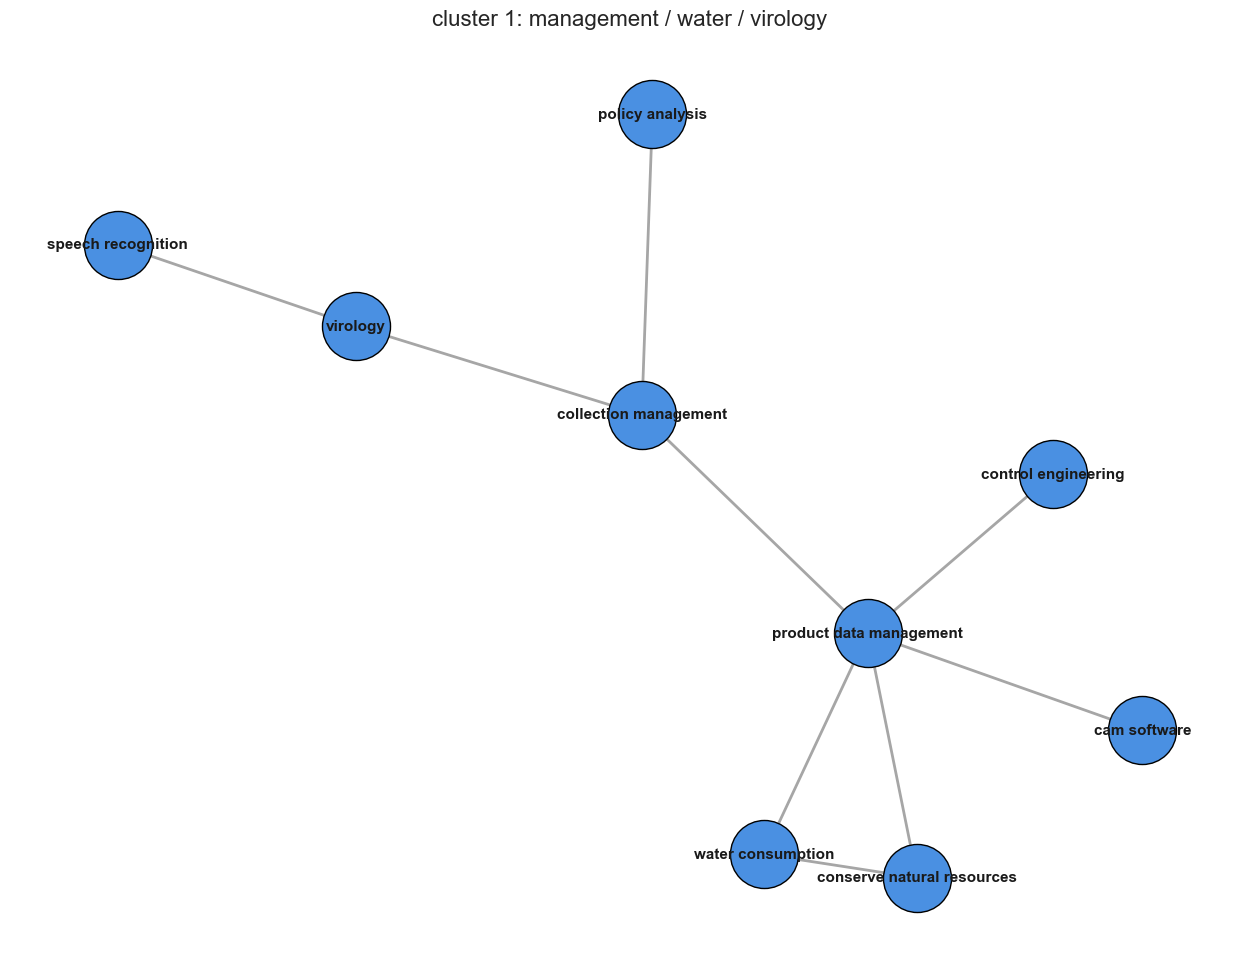

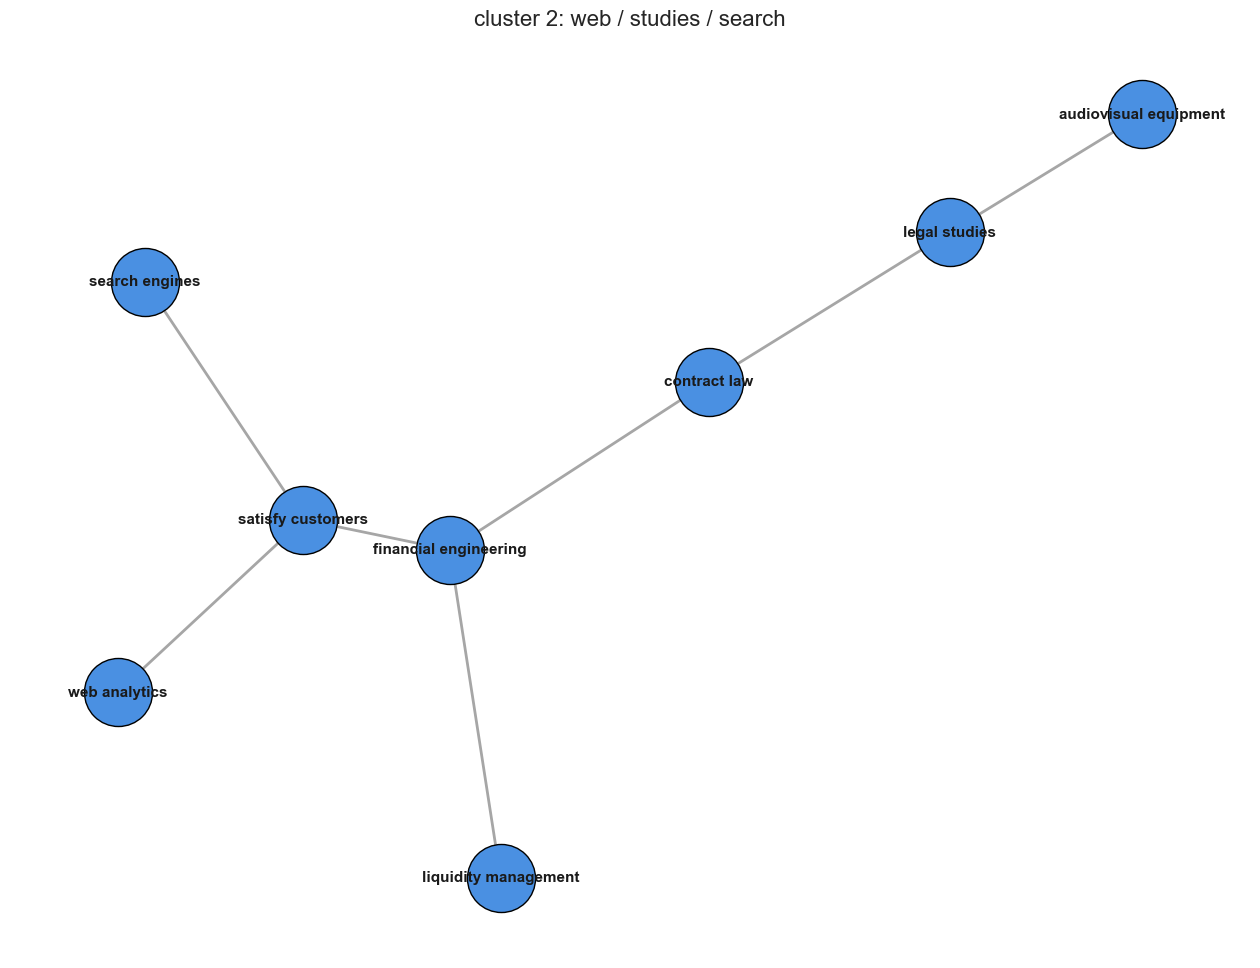

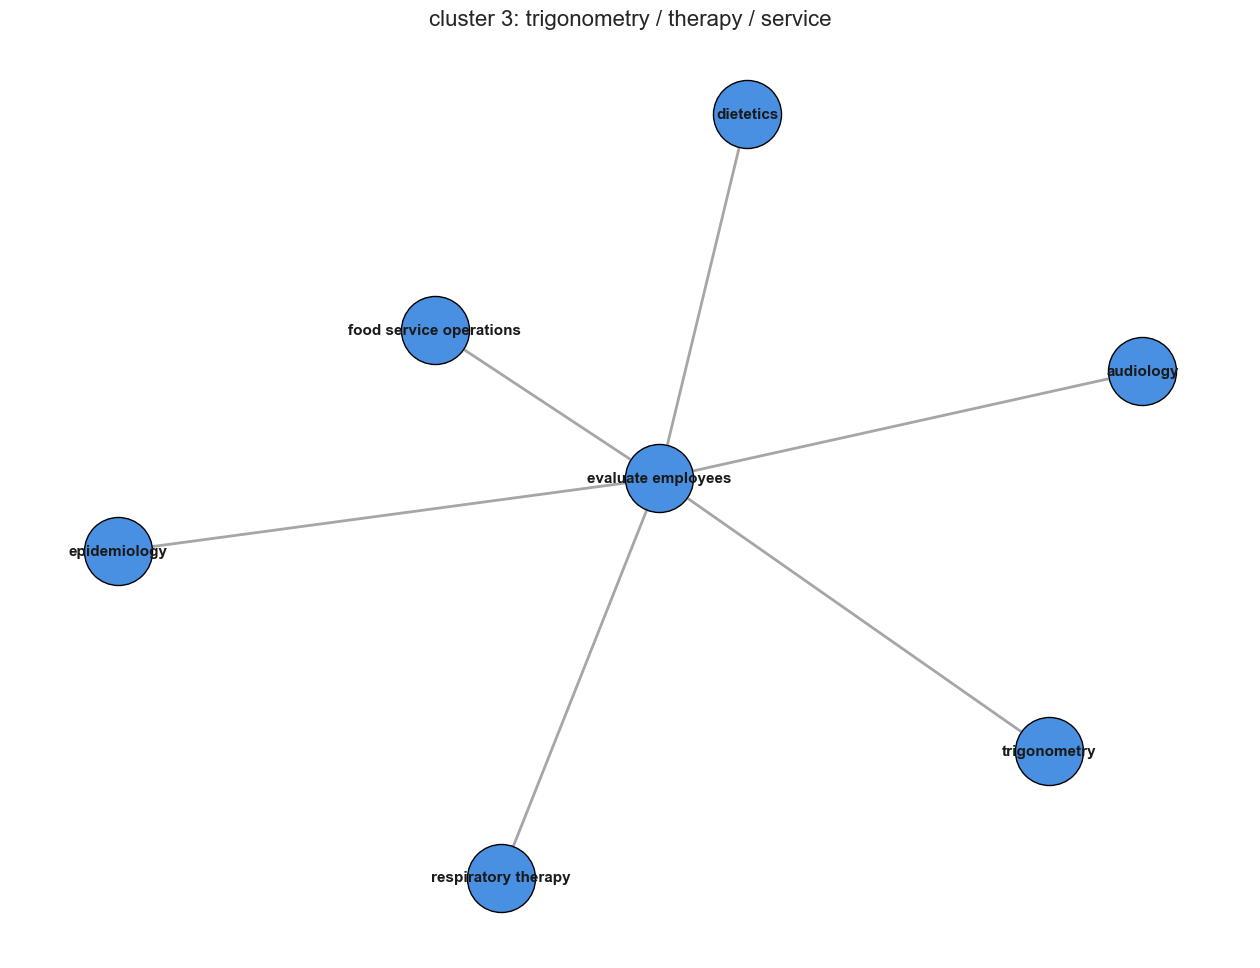

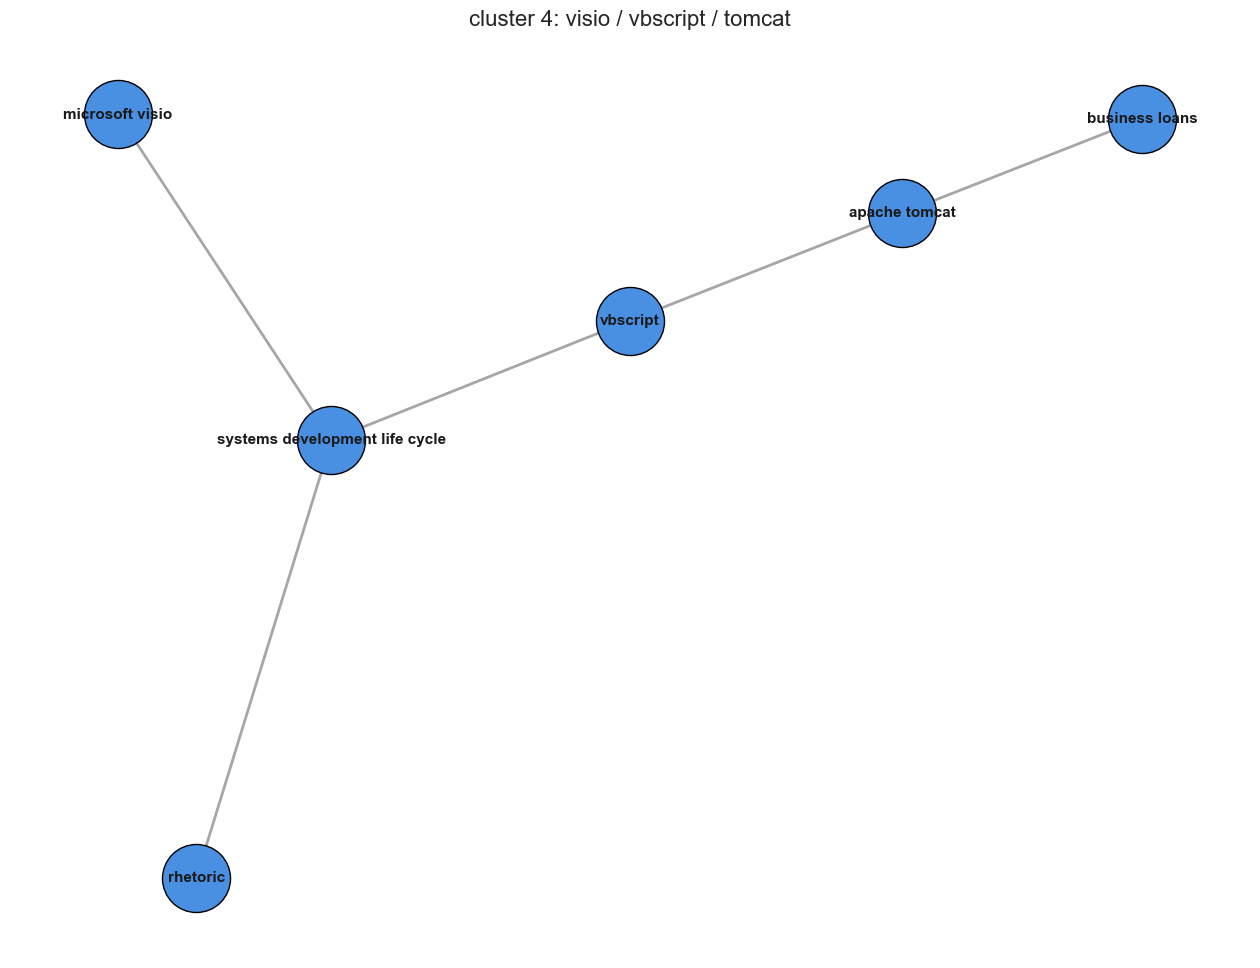

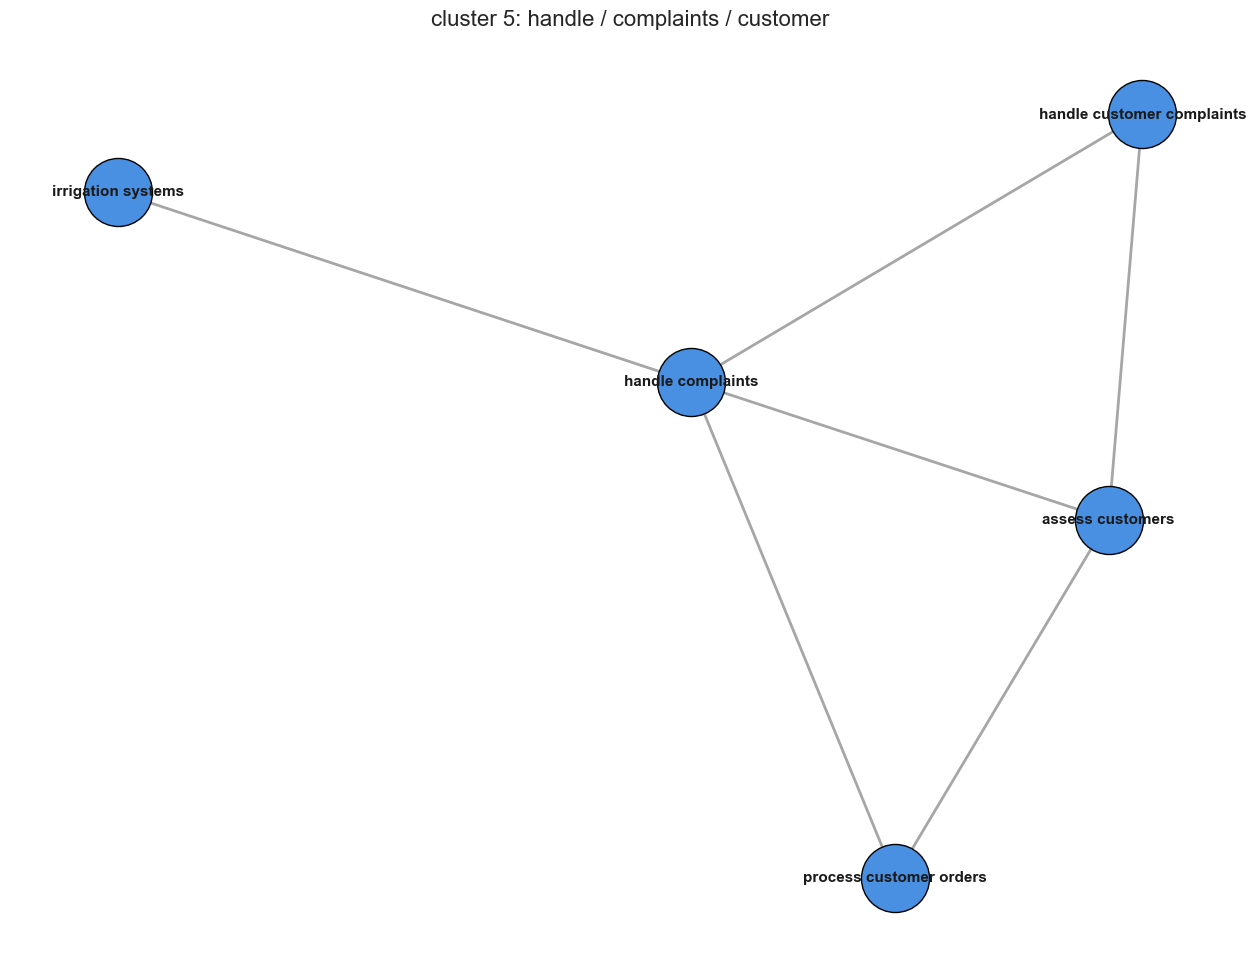

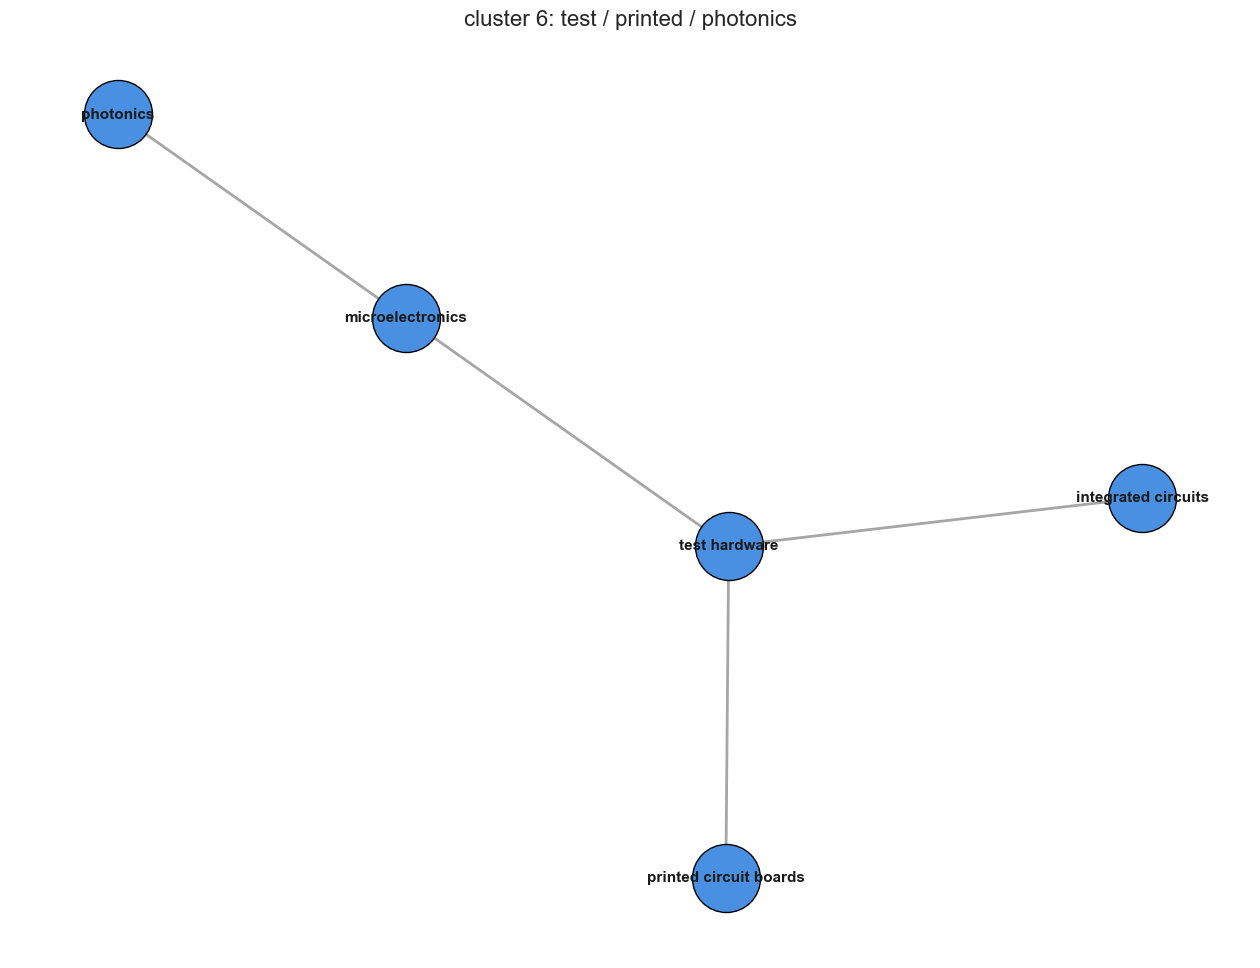

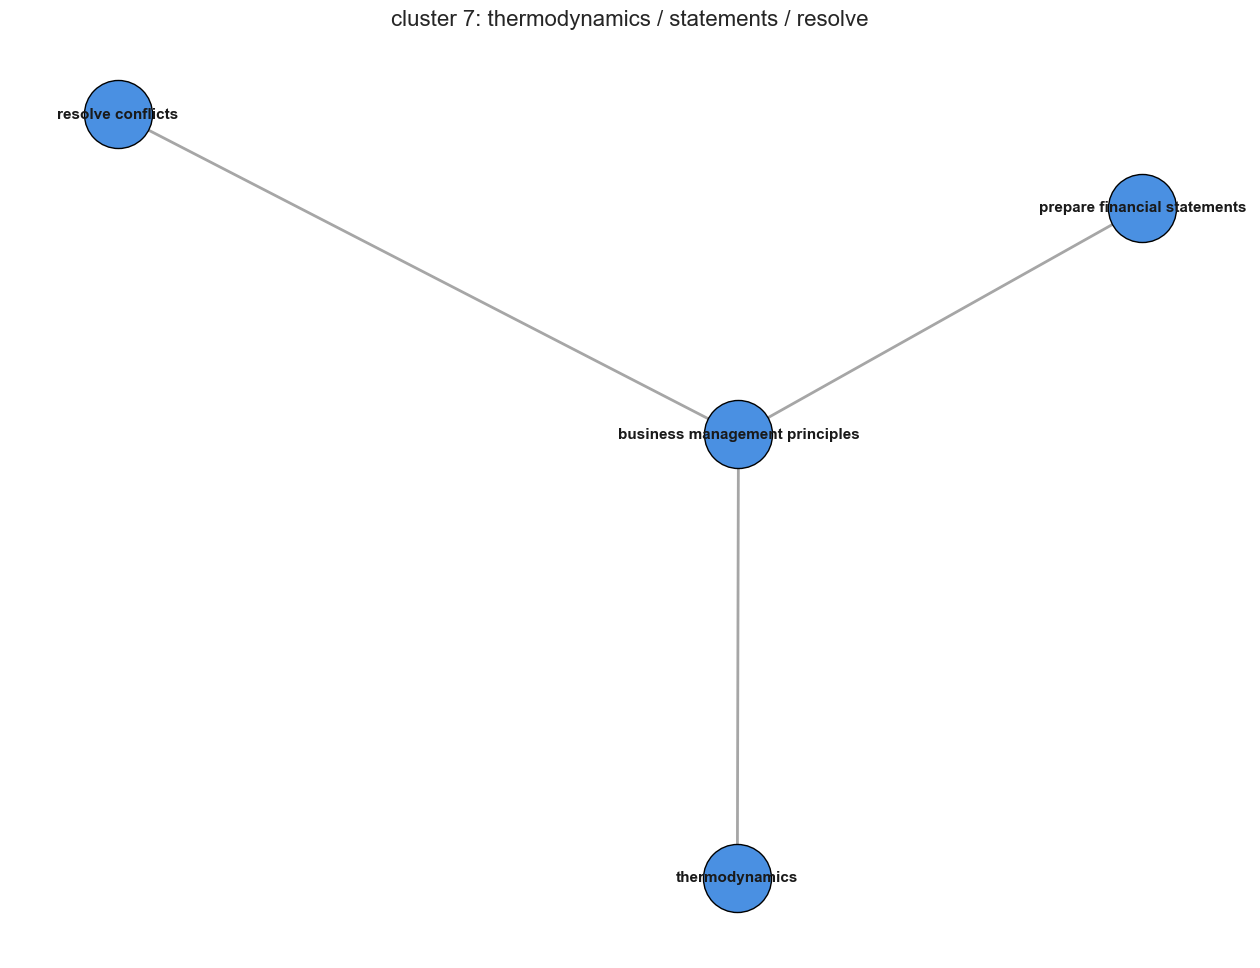

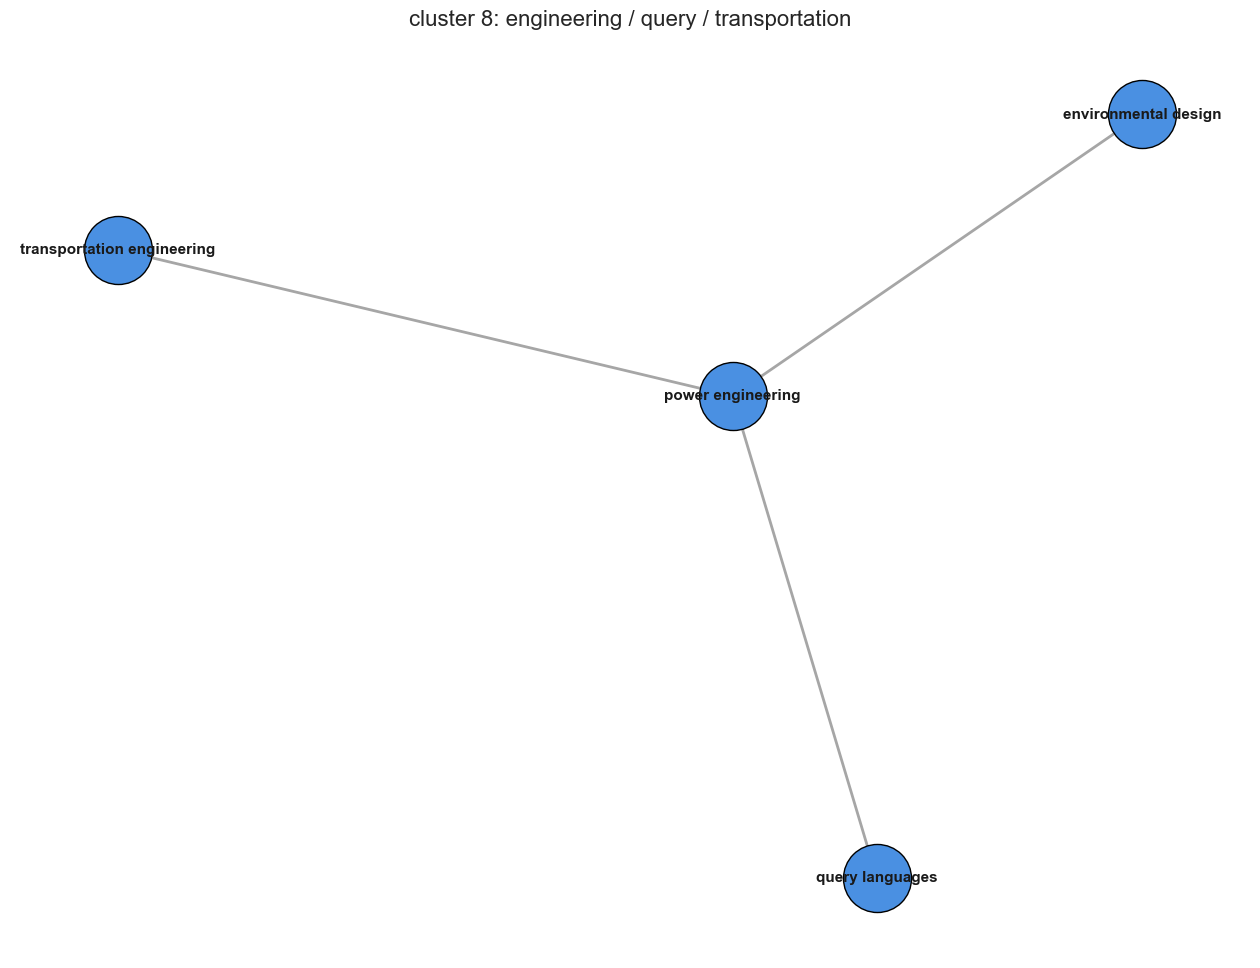

In [52]:
for cid, comm in enumerate(communities):
    if len(comm) >= 4:
        plot_community(G, comm, cid)

## 4.7 Kết luận

Thông qua việc kết hợp **ESCO skills ontology** với phân tích đồng xuất hiện kỹ năng trong mô tả công việc, nghiên cứu đã khai phá thành công các **skill bundles** – những nhóm kỹ năng có xu hướng xuất hiện cùng nhau trong thực tế tuyển dụng. Bằng cách sử dụng các thước đo **support, confidence và lift**, các mối quan hệ kỹ năng yếu hoặc ngẫu nhiên đã được loại bỏ, giúp tập trung vào những liên kết có ý nghĩa thống kê và giá trị thực tiễn.

Kết quả cho thấy các kỹ năng không tồn tại độc lập mà được tổ chức thành các **cụm kỹ năng đặc trưng theo lĩnh vực**, bao gồm các nhóm nổi bật như kỹ thuật – công nghệ – năng lượng, y tế – khoa học đời sống, quản lý – chính sách – pháp lý, cũng như các nhóm kỹ năng quản trị và kỹ năng mềm. Các skill bundles thu được phản ánh sát nhu cầu của thị trường lao động, vì chúng được trích xuất trực tiếp từ dữ liệu tuyển dụng thực tế thay vì dựa trên phân loại lý thuyết sẵn có.

Như vậy, **RQ2 đã làm rõ cấu trúc kỹ năng ẩn của thị trường lao động**, cung cấp góc nhìn sâu hơn về cách các kỹ năng được kết hợp trong từng vai trò nghề nghiệp. Kết quả này có tiềm năng ứng dụng trong thiết kế chương trình đào tạo, tư vấn nghề nghiệp, cũng như hỗ trợ người lao động xác định các bộ kỹ năng cần phát triển để phù hợp với yêu cầu tuyển dụng hiện nay.

# 5. RQ3 – Phân tích & dự đoán lương

## 5.1 Xử lí biến mục tiêu

In [53]:
df = job_merged.copy()

# salary
df.loc[
    (job_merged["normalized_salary"] < 10_000)
    | (job_merged["normalized_salary"] > 500_000),
    "normalized_salary",
] = np.nan

df["log_salary"] = np.log1p(df["normalized_salary"])
df = df.dropna(subset=["log_salary"]).copy()

## 5.2 Tạo Feature Engineering

In [54]:
def _to_num(s):
    return pd.to_numeric(s, errors="coerce")


def list_len(x):
    return len(x) if isinstance(x, list) else 0


# số lượng kí tự
df["desc_len"] = df["description"].str.len()

df["num_skills"] = df["skills_list"].apply(list_len)
df["num_linkedin_skills"] = df["linkedin_skills"].apply(list_len)


# apply_rate
df["apply_rate"] = _to_num(df["applies"]) / (_to_num(df["views"]) + 1)

df["remote_allowed"] = _to_num(df["remote_allowed"])


### 5.2.1 Trực quan hóa

#### 5.2.1.1 Phân phối độ dài mô tả công việc

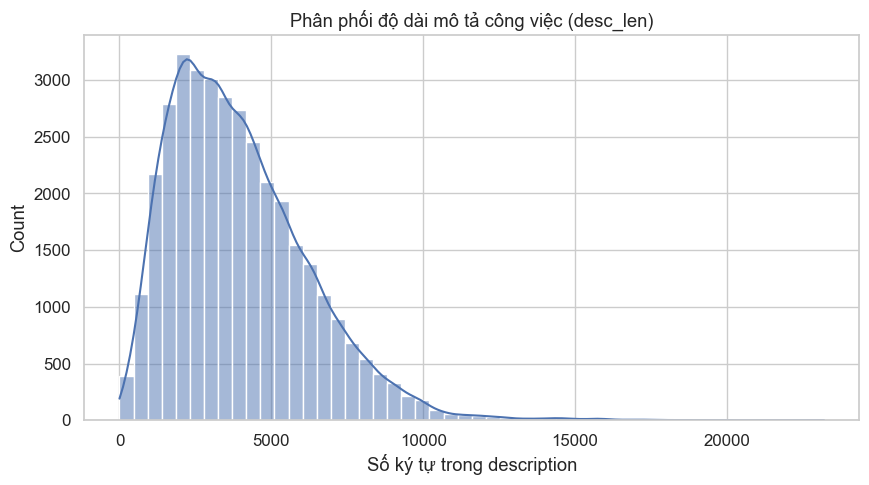

In [55]:
sns.histplot(df["desc_len"], bins=50, kde=True)
plt.xlabel("Số ký tự trong description")
plt.title("Phân phối độ dài mô tả công việc (desc_len)")
plt.show()

#### 5.2.1.2 Biểu đồ phân phối lương

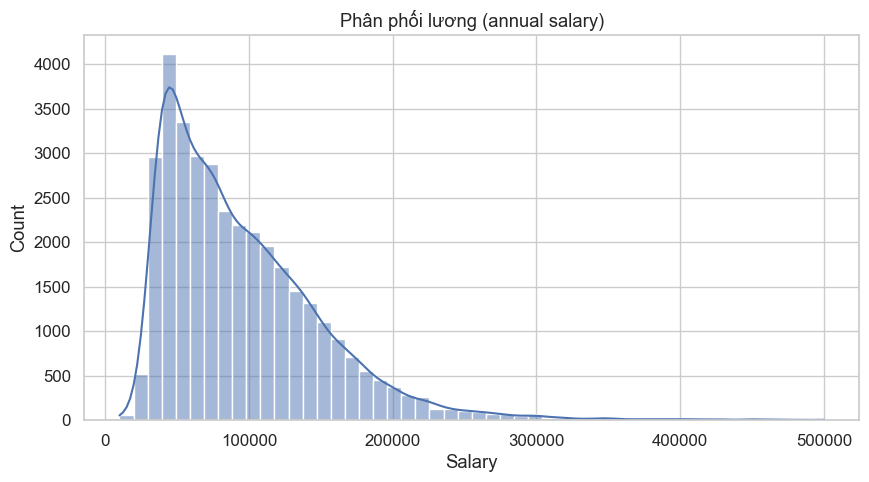

In [56]:
sns.histplot(df["normalized_salary"], bins=50, kde=True)
plt.xlabel("Salary")
plt.title("Phân phối lương (annual salary)")
plt.show()

#### 5.2.1.3 Biểu đồ so sánh lương theo cấp độ kinh nghiệm

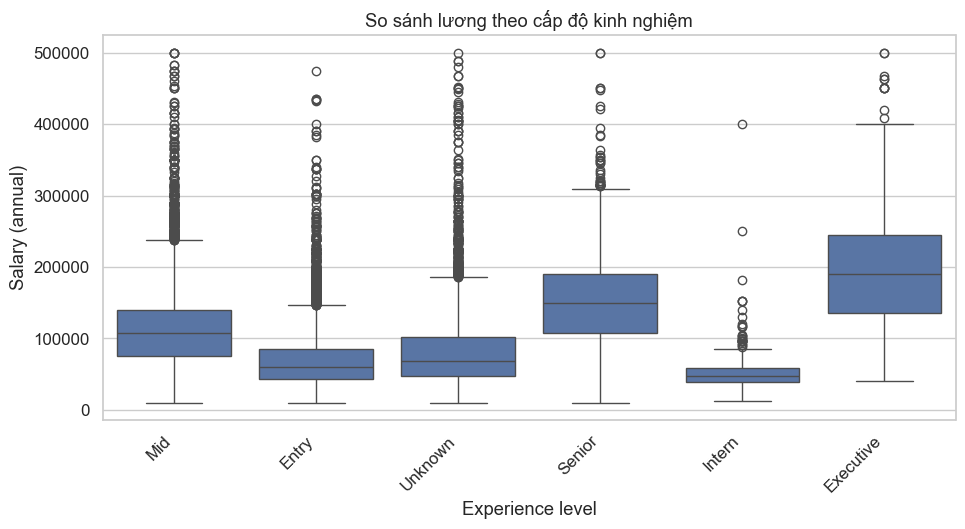

In [57]:
order = df["formatted_experience_level"].value_counts().index.tolist()
plt.figure(figsize=(11, 5))
sns.boxplot(data=df, x="formatted_experience_level", y="normalized_salary", order=order)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Experience level")
plt.ylabel("Salary (annual)")
plt.title("So sánh lương theo cấp độ kinh nghiệm")
plt.show()

#### 5.2.1.4 Biểu đồ so sánh lương theo remote_allowed

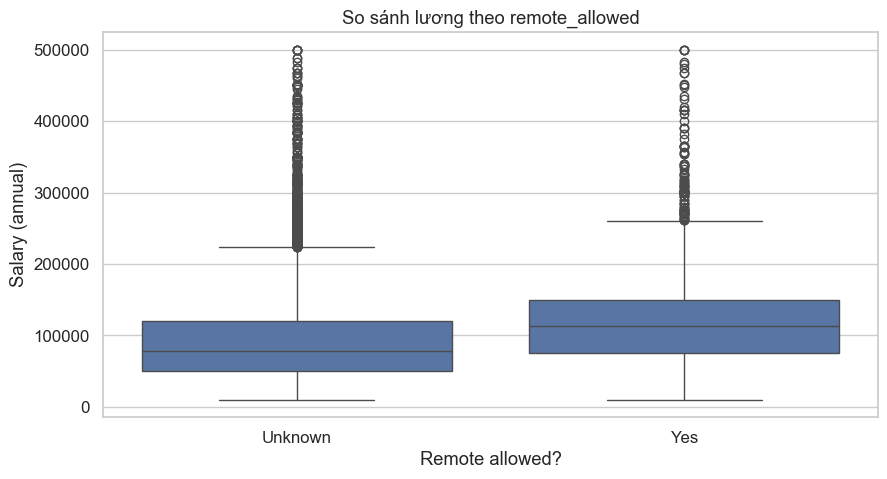

In [58]:
# remote_allowed đôi khi là float/NaN -> đưa về 0/1/Unknown
tmp = df.copy()
tmp["remote_allowed_clean"] = (
    tmp["remote_allowed"]
    .fillna(-1)
    .astype(int)
    .replace({-1: "Unknown", 0: "No", 1: "Yes"})
)
sns.boxplot(data=tmp, x="remote_allowed_clean", y="normalized_salary")
plt.xlabel("Remote allowed?")
plt.ylabel("Salary (annual)")
plt.title("So sánh lương theo remote_allowed")
plt.show()

#### 5.2.1.5 Biểu đồ so sánh lương theo quy mô công ty

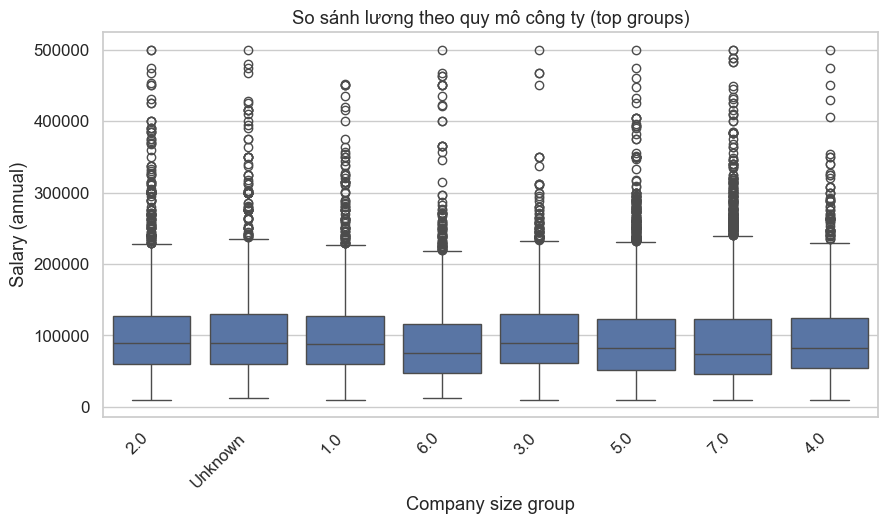

In [59]:
tmp = df.copy()
tmp["company_size"] = tmp["company_size"].fillna("Unknown")
# chỉ lấy top nhóm để dễ nhìn
top_sizes = tmp["company_size"].value_counts().head(8).index
tmp = tmp[tmp["company_size"].isin(top_sizes)]
sns.boxplot(data=tmp, x="company_size", y="normalized_salary")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Company size group")
plt.ylabel("Salary (annual)")
plt.title("So sánh lương theo quy mô công ty (top groups)")
plt.show()

## 5.3 Chọn features

In [60]:
target_col = "log_salary"

numeric_features = [
    "views",
    "applies",
    "employee_count",
    "follower_count",
    "desc_len",
    "num_skills",
    "num_linkedin_skills",
    "apply_rate",
    "remote_allowed",
]

categorical_features = [
    "country",
    "state",
    "city",
    "formatted_experience_level",
    "formatted_work_type",
    "company_size",
    "application_type",
    "currency",
]

## 5.4 Chia tập dữ liệu Train/Test

In [61]:
X = df[numeric_features + categorical_features].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### 5.4.1 Feature Engineering trên Train

In [62]:
# Fit country_mean_salary on TRAIN only
if "country" in X_train.columns:
    train_country_mean = (
        pd.DataFrame({"country": X_train["country"], "salary": np.expm1(y_train)})
        .groupby("country")["salary"]
        .mean()
    )
    X_train["country_mean_salary"] = X_train["country"].map(train_country_mean)
    X_test["country_mean_salary"] = X_test["country"].map(train_country_mean)

### 5.4.2 Feature Engineering trên Test

In [63]:
# if unseen countries in test -> fill with global mean (train)
global_mean = np.expm1(y_train).mean()
if "country_mean_salary" in X_train.columns:
    X_train["country_mean_salary"] = X_train["country_mean_salary"].fillna(global_mean)
    X_test["country_mean_salary"] = X_test["country_mean_salary"].fillna(global_mean)

print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Train shape: (28448, 18) | Test shape: (7112, 18)
Numeric: ['views', 'applies', 'employee_count', 'follower_count', 'desc_len', 'num_skills', 'num_linkedin_skills', 'apply_rate', 'remote_allowed']
Categorical: ['country', 'state', 'city', 'formatted_experience_level', 'formatted_work_type', 'company_size', 'application_type', 'currency']


## 5.5 Pipeline tiền xử lý

In [64]:
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

## 5.6 Huấn luyện mô hình Random Forest

In [65]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=24,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42,
)

model = Pipeline(steps=[("preprocess", preprocess), ("model", rf)])

# Train
model.fit(X_train[numeric_features + categorical_features], y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 5.7 Đánh giá mô hình

In [66]:
# Predict (log)
y_pred_log = model.predict(X_test[numeric_features + categorical_features])

# Evaluate trên salary gốc
y_true = np.expm1(y_test)
y_pred = np.expm1(y_pred_log)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"\nRMSE={rmse:,.0f} | MAE={mae:,.0f} | R²={r2:.3f}")


RMSE=43,005 | MAE=27,603 | R²=0.433


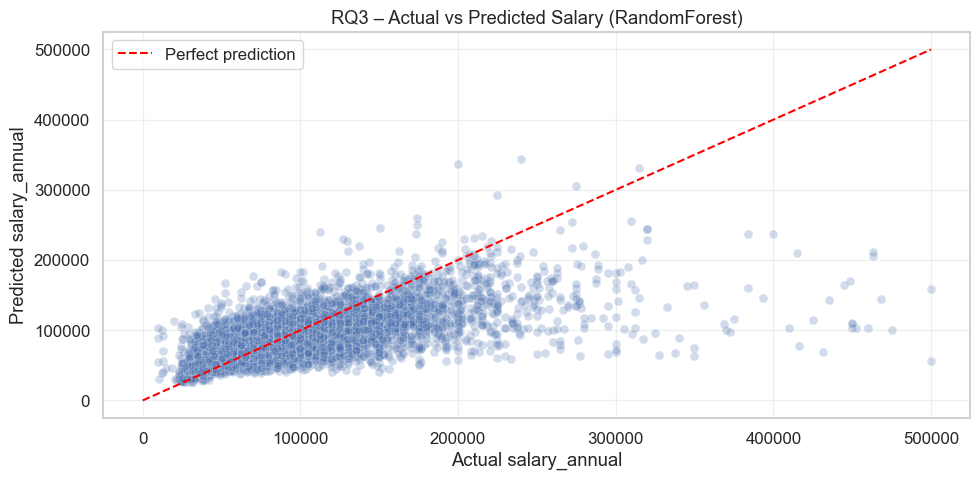

In [67]:
# Tạo DataFrame cho seaborn
plot_df = pd.DataFrame({"Actual salary": y_true, "Predicted salary": y_pred})

plt.figure(figsize=(10, 5))

sns.scatterplot(data=plot_df, x="Actual salary", y="Predicted salary", alpha=0.25, s=40)

# Đường dự đoán hoàn hảo
mx = max(plot_df.max())
plt.plot([0, mx], [0, mx], "--", color="red", label="Perfect prediction")

plt.title("RQ3 – Actual vs Predicted Salary (RandomForest)")
plt.xlabel("Actual salary_annual")
plt.ylabel("Predicted salary_annual")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5.8 Phân tích tầm quan trọng đặc trưng

In [68]:
X_test = X_test[numeric_features + categorical_features].copy()

perm = permutation_importance(
    model,
    X_test,
    y_test,  # y ở log space cho đúng pipeline
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_squared_error",
)

perm_df = pd.DataFrame(
    {
        "feature": X_test.columns,
        "perm_mean": perm.importances_mean,
        "perm_std": perm.importances_std,
    }
).sort_values("perm_mean", ascending=False)

display(perm_df)


,feature,perm_mean,perm_std
12,formatted_experience_level,1.340604e-01,2.601613e-03
3,follower_count,6.603671e-02,1.169103e-03
2,employee_count,3.970372e-02,1.031652e-03
5,num_skills,2.321453e-02,1.445651e-03
4,desc_len,2.204498e-02,8.970000e-04
13,formatted_work_type,1.428410e-02,1.219965e-03
15,application_type,1.391697e-02,7.148918e-04
10,state,1.189905e-02,5.807716e-04
11,city,8.831632e-03,4.737921e-04
0,views,7.009655e-03,5.706496e-04


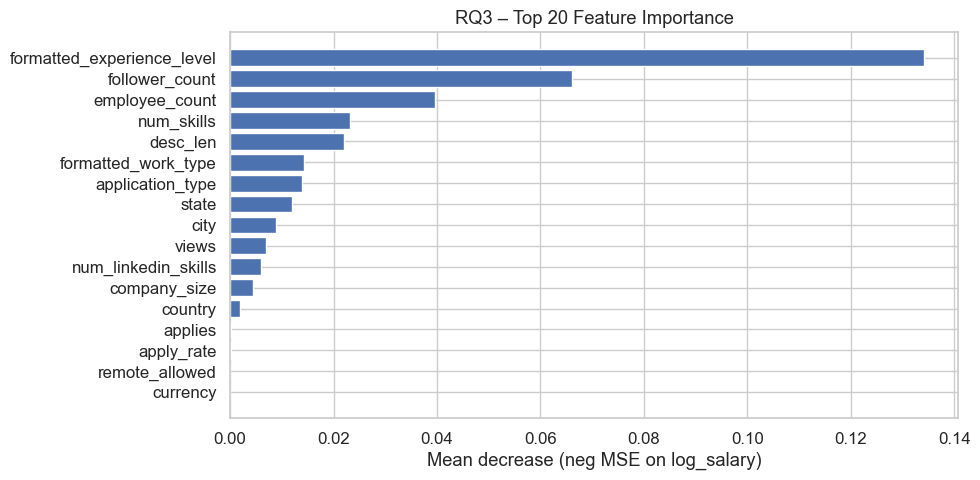

In [69]:
topN = 20
plt.barh(perm_df.head(topN)["feature"][::-1], perm_df.head(topN)["perm_mean"][::-1])
plt.title("RQ3 – Top 20 Feature Importance")
plt.xlabel("Mean decrease (neg MSE on log_salary)")
plt.tight_layout()
plt.show()

# Kết thúc